# Applying the Models

In [1]:
# Loaded all the libraries because I'll be using a whole lot

# Core Libraries
import warnings
import os
import glob
import joblib

import numpy as np
import pandas as pd
from scipy.stats.mstats import winsorize

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from scipy.spatial.distance import cosine

warnings.filterwarnings("ignore")
from scipy.stats.mstats import winsorize

# Clean plot style
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# Optional display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# Scikit-Learn: Model Selection / Validation
from sklearn.model_selection import (
    train_test_split,
    KFold,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV,
)

# Scikit-Learn: Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Scikit-Learn: Regression Models
from sklearn.linear_model import LinearRegression

# Scikit-Learn: Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.linear_model import Lasso

# Scikit-Learn: Ensemble Models
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier,
    BaggingClassifier,
)


from matplotlib.ticker import PercentFormatter

# Scikit-Learn: Metrics
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics.pairwise import cosine_similarity

# Gradient Boosting Libraries
import xgboost as xgb
import lightgbm as lgb

# Interpretability
import shap

# Association Rules
from mlxtend.frequent_patterns import apriori, association_rules

from matplotlib.ticker import PercentFormatter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import hashlib
import os
import warnings

from scipy.stats import spearmanr
import statsmodels.api as sm

warnings.filterwarnings("ignore")



print("✅ Libraries loaded!")

# Define random state
RANDOM_STATE = 51

import yfinance as yf

✅ Libraries loaded!


In [2]:
# Load the best model from the joblib file and files

model = joblib.load("best_model.joblib")

df_test = pd.read_csv("df_test.csv")
X_test = pd.read_csv("X_test_shared_XGBoost.csv")

print("df_test shape:", df_test.shape)
print("X_test shape:", X_test.shape)
print("Model expected features:", model.n_features_in_)

df_test shape: (3464, 768)
X_test shape: (3464, 654)
Model expected features: 654


In [3]:
df_test = df_test.loc[:, ~df_test.columns.str.startswith("Unnamed")].copy() # Remove any unnamed columns from df_test

X_test = X_test.loc[:, ~X_test.columns.str.startswith("Unnamed")].copy() # Remove any unnamed columns from X_test

print("Clean df_test shape:", df_test.shape)
print("Clean X_test shape:", X_test.shape)
df_test = df_test.rename(columns={"index": "original_row_id"})

display(df_test.head())
X_test.head()

Clean df_test shape: (3464, 767)
Clean X_test shape: (3464, 654)


,original_row_id,ticker,fiscal_year,fiscal_period,period_end_date,inc_currency,inc_revenue,inc_revenue_product,inc_revenue_services,inc_cost_of_revenue,inc_gross_profit,inc_operating_expenses,inc_research_development,inc_selling_general_administrative,inc_selling_marketing_expenses,inc_general_admin_expenses,inc_depreciation_amortization,inc_depreciation,inc_amortization_of_intangibles,inc_stock_based_compensation,inc_operating_income,inc_interest_expense,inc_interest_income,inc_other_income_expense,inc_income_before_taxes,inc_income_tax_expense,inc_net_income_continuing_operations,inc_net_income_discontinued_operations,inc_net_income,inc_basic_shares_outstanding,inc_diluted_shares_outstanding,inc_weighted_average_basic_shares,inc_weighted_average_diluted_shares,inc_basic_eps,inc_diluted_eps,inc_dividends_per_share,inc_comprehensive_income,inc_other_comprehensive_income,inc_impairment_charges,inc_restructuring_costs,inc_net_income_noncontrolling_interest,inc_preferred_dividends,inc_net_income_available_to_common,inc_revenue_from_contracts_excluding_tax,inc_revenue_from_contracts_including_tax,inc_income_before_taxes_and_extraordinary,inc_other_comprehensive_income_net_of_tax,inc_comprehensive_income_net_of_tax,inc_interest_income_operating,api_ticker_used,bal_currency,bal_total_assets,bal_current_assets,bal_non_current_assets,bal_cash_and_equivalents,bal_short_term_investments,bal_long_term_investments,bal_accounts_receivable,bal_inventory,bal_property_plant_equipment,bal_goodwill,bal_intangible_assets,bal_other_current_assets,bal_other_non_current_assets,bal_prepaid_expenses,bal_total_liabilities,bal_current_liabilities,bal_non_current_liabilities,bal_accounts_payable,bal_accruals_current,bal_short_term_debt,bal_deferred_revenue_current,bal_other_current_liabilities,bal_long_term_debt,bal_deferred_tax_liabilities,bal_deferred_revenue_non_current,bal_other_non_current_liabilities,bal_accrued_liabilities,bal_total_equity,bal_retained_earnings,bal_additional_paid_in_capital,bal_treasury_stock,bal_treasury_shares,bal_accumulated_other_comprehensive_income,bal_noncontrolling_interest,bal_preferred_stock_value,bal_operating_lease_right_of_use_assets,bal_operating_lease_liability_current,bal_operating_lease_liability_noncurrent,bal_investment_securities_fair_value,bal_available_for_sale_debt_securities,bal_common_stock_shares_authorized,bal_shares_issued,bal_common_stock_par_value_per_share,bal_total_debt,bal_net_debt,bal_working_capital,bal_tangible_book_value,bal_book_value_per_share,cf_currency,cf_net_cash_from_operations,cf_deferred_taxes,cf_change_in_receivables,cf_change_in_inventory,cf_change_in_accounts_payable,cf_change_in_deferred_revenue,cf_other_operating_assets_change,cf_other_operating_liabilities_change,cf_tax_withholding_payments,cf_other_misc_operating,cf_net_cash_from_investing,cf_capital_expenditures,cf_acquisitions,cf_purchase_of_investments,cf_proceeds_from_investments,cf_recurring_capital_expenditures,cf_net_cash_from_financing,cf_issuance_of_debt,cf_repayment_of_debt,cf_repurchase_of_stock,cf_cash_at_beginning_of_period,cf_cash_at_end_of_period,cf_net_change_in_cash,cf_free_cash_flow,cf_levered_free_cash_flow,shr_basic_shares_outstanding,shr_diluted_shares_outstanding,shr_weighted_average_basic_shares,shr_weighted_average_diluted_shares,shr_treasury_shares,shr_dilution_percentage,shr_is_buyback,profile_api_ticker_used,sector,industry,company_name,fiscal_year_end,website_url,exchange,buyback_quarter,inc_net_interest_income,inc_provision_for_credit_losses,inc_net_interest_margin,inc_return_on_average_assets,inc_return_on_average_equity,inc_fee_income,inc_trading_revenue,inc_interest_income_loans_commercial,inc_interest_income_loans_consumer,inc_interest_income_loans_total,inc_interest_income_securities,inc_interest_expense_deposits,inc_interest_expense_borrowings,inc_interest_expense_long_term_debt,inc_net_interest_income_after_provision,inc_investment_banking_revenue,inc_asset_management_fees,inc_service_charge

,fiscal_year,inc_revenue,inc_cost_of_revenue,inc_gross_profit,inc_operating_expenses,inc_selling_general_administrative,inc_depreciation_amortization,inc_stock_based_compensation,inc_operating_income,inc_interest_expense,inc_other_income_expense,inc_income_before_taxes,inc_income_tax_expense,inc_net_income_continuing_operations,inc_net_income,inc_basic_shares_outstanding,inc_weighted_average_basic_shares,inc_weighted_average_diluted_shares,inc_basic_eps,inc_diluted_eps,inc_comprehensive_income,inc_other_comprehensive_income,inc_net_income_available_to_common,inc_income_before_taxes_and_extraordinary,inc_other_comprehensive_income_net_of_tax,inc_comprehensive_income_net_of_tax,bal_total_assets,bal_current_assets,bal_non_current_assets,bal_cash_and_equivalents,bal_accounts_receivable,bal_property_plant_equipment,bal_goodwill,bal_intangible_assets,bal_other_current_assets,bal_other_non_current_assets,bal_total_liabilities,bal_current_liabilities,bal_non_current_liabilities,bal_accounts_payable,bal_accruals_current,bal_long_term_debt,bal_other_non_current_liabilities,bal_total_equity,bal_retained_earnings,bal_additional_paid_in_capital,bal_accumulated_other_comprehensive_income,bal_operating_lease_right_of_use_assets,bal_common_stock_shares_authorized,bal_shares_issued,bal_common_stock_par_value_per_share,bal_total_debt,bal_net_debt,bal_working_capital,bal_tangible_book_value,bal_book_value_per_share,cf_net_cash_from_operations,cf_change_in_receivables,cf_change_in_accounts_payable,cf_other_operating_assets_change,cf_net_cash_from_investing,cf_capital_expenditures,cf_net_cash_from_financing,cf_cash_at_beginning_of_period,cf_cash_at_end_of_period,cf_net_change_in_cash,cf_free_cash_flow,cf_levered_free_cash_flow,shr_basic_shares_outstanding,shr_weighted_average_basic_shares,shr_weighted_average_diluted_shares,fiscal_year_end,buyback_quarter,price_close_q,basic_market_cap_q,avg_total_assets_q,avg_total_equity_q,avg_total_liabilities_q,avg_total_debt_q,avg_accounts_receivable_q,avg_accounts_payable_q,avg_working_capital_q,avg_ppe_q,gross_margin_q,operating_margin_q,net_margin_q,pretax_margin_q,common_earnings_margin_q,continuing_operations_margin_q,SG&A_intensity_q,D&A_intensity_q,stock_comp_intensity_q,comprehensive_income_margin_q,tax_burden_ratio_q,effective_tax_rate_q,ROA_q,ROE_q,operating_ROA_q,pretax_ROA_q,cash_ROA_q,FCF_ROA_q,current_ratio_q,cash_ratio_q,working_capital_to_assets_q,cash_to_assets_q,debt_to_equity_q,debt_to_assets_q,liabilities_to_assets_q,net_debt_to_assets_q,net_debt_to_equity_q,long_term_debt_to_capital_q,long_term_debt_share_q,cash_to_debt_q,asset_turnover_q,receivables_turnover_q,payables_turnover_q,ppe_turnover_q,days_sales_outstanding_q,days_payables_outstanding_q,OFC_margin_q,FCF_margin_q,levered_FCF_margin_q,OCF_to_net_income_q,FCF_to_net_income_q,OCF_to_liabilities_q,FCF_to_debt_q,capex_to_revenue_q,capex_to_assets_q,cash_conversion_ratio_q,financing_cash_flows_to_assets_q,share_count_change_pct_q,sales_per_share_q,OCF_per_share_q,FCF_per_share_q,tangible_book_value_per_share_q,cash_per_share_q,net_debt_per_share_q,P/B_q,P/S_q,P/OCF_q,P/FCF_q,OCF_yield_q,FCF_yield_q,revenue_growth_qoq,gross_profit_growth_qoq,net_income_growth_qoq,OCF_growth_qoq,assets_growth_qoq,debt_growth_qoq,revenue_growth_yoy,assets_growth_yoy,shr_pct_change_yoy,accrual_ratio_q,stock_compensation_to_revenue_q,goodwill_to_assets_q,intangibles_to_assets_q,AOCI_to_equity_q,fuel_cost_ratio_q,purchased_power_ratio_q,transmission_expense_ratio_q,storm_damage_ratio_q,rate_base_turnover_q,revenue_per_mwh_q,regulatory_assets_to_assets_q,regulatory_liabilities_to_liabilities_q,renewable_energy_credit_revenue_share_q,gas_utility_revenue_share_q,allowed_rate_of_return_q,renewable_energy_percentage_q,revenue_per_customer_q,mwh_per_customer_q,residential_revenue_mix_q,commercial_revenue_mix_q,industrial_revenue_mix_q,wholesale_revenue_mix_q,generation_plant_intensity_q,transmission_plant_intensity_q,distribution_plant_intensity_q,cwip_to_assets_

In [4]:
# Generate frozen buyback probabilities using the best model:

buyback_prob = model.predict_proba(X_test)[:, 1]

master = df_test.copy()
master["buyback_prob"] = buyback_prob

master["buyback_prob"].describe()

# Convert the date column to datetime format:

dates_to_convert = [
    col for col in master.columns
    if any(word in col.lower() for word in [
        "date", "period", "quarter", "fiscal"])    # how to search for specific words in a list of strings
]

display(dates_to_convert)

# Create and sort new dataset:

master["period_end_date"] = pd.to_datetime(master["period_end_date"], errors="coerce")

master = master.dropna(subset=["period_end_date"]).copy() # new parameter: subset
master.drop("original_row_id", axis=1, inplace=True)
display(master.head())

master = master.sort_values(["ticker", "period_end_date"]).reset_index(drop=True)
display(master.head())

master.to_csv("outputs and master_test_with_buyback_probability.csv", index=False)

['fiscal_year',
 'fiscal_period',
 'period_end_date',
 'cf_cash_at_beginning_of_period',
 'cf_cash_at_end_of_period',
 'fiscal_year_end',
 'buyback_quarter',
 'inc_properties_acquired_during_period',
 'inc_properties_disposed_during_period',
 'price_date',
 'buyback_next_quarter']

,ticker,fiscal_year,fiscal_period,period_end_date,inc_currency,inc_revenue,inc_revenue_product,inc_revenue_services,inc_cost_of_revenue,inc_gross_profit,inc_operating_expenses,inc_research_development,inc_selling_general_administrative,inc_selling_marketing_expenses,inc_general_admin_expenses,inc_depreciation_amortization,inc_depreciation,inc_amortization_of_intangibles,inc_stock_based_compensation,inc_operating_income,inc_interest_expense,inc_interest_income,inc_other_income_expense,inc_income_before_taxes,inc_income_tax_expense,inc_net_income_continuing_operations,inc_net_income_discontinued_operations,inc_net_income,inc_basic_shares_outstanding,inc_diluted_shares_outstanding,inc_weighted_average_basic_shares,inc_weighted_average_diluted_shares,inc_basic_eps,inc_diluted_eps,inc_dividends_per_share,inc_comprehensive_income,inc_other_comprehensive_income,inc_impairment_charges,inc_restructuring_costs,inc_net_income_noncontrolling_interest,inc_preferred_dividends,inc_net_income_available_to_common,inc_revenue_from_contracts_excluding_tax,inc_revenue_from_contracts_including_tax,inc_income_before_taxes_and_extraordinary,inc_other_comprehensive_income_net_of_tax,inc_comprehensive_income_net_of_tax,inc_interest_income_operating,api_ticker_used,bal_currency,bal_total_assets,bal_current_assets,bal_non_current_assets,bal_cash_and_equivalents,bal_short_term_investments,bal_long_term_investments,bal_accounts_receivable,bal_inventory,bal_property_plant_equipment,bal_goodwill,bal_intangible_assets,bal_other_current_assets,bal_other_non_current_assets,bal_prepaid_expenses,bal_total_liabilities,bal_current_liabilities,bal_non_current_liabilities,bal_accounts_payable,bal_accruals_current,bal_short_term_debt,bal_deferred_revenue_current,bal_other_current_liabilities,bal_long_term_debt,bal_deferred_tax_liabilities,bal_deferred_revenue_non_current,bal_other_non_current_liabilities,bal_accrued_liabilities,bal_total_equity,bal_retained_earnings,bal_additional_paid_in_capital,bal_treasury_stock,bal_treasury_shares,bal_accumulated_other_comprehensive_income,bal_noncontrolling_interest,bal_preferred_stock_value,bal_operating_lease_right_of_use_assets,bal_operating_lease_liability_current,bal_operating_lease_liability_noncurrent,bal_investment_securities_fair_value,bal_available_for_sale_debt_securities,bal_common_stock_shares_authorized,bal_shares_issued,bal_common_stock_par_value_per_share,bal_total_debt,bal_net_debt,bal_working_capital,bal_tangible_book_value,bal_book_value_per_share,cf_currency,cf_net_cash_from_operations,cf_deferred_taxes,cf_change_in_receivables,cf_change_in_inventory,cf_change_in_accounts_payable,cf_change_in_deferred_revenue,cf_other_operating_assets_change,cf_other_operating_liabilities_change,cf_tax_withholding_payments,cf_other_misc_operating,cf_net_cash_from_investing,cf_capital_expenditures,cf_acquisitions,cf_purchase_of_investments,cf_proceeds_from_investments,cf_recurring_capital_expenditures,cf_net_cash_from_financing,cf_issuance_of_debt,cf_repayment_of_debt,cf_repurchase_of_stock,cf_cash_at_beginning_of_period,cf_cash_at_end_of_period,cf_net_change_in_cash,cf_free_cash_flow,cf_levered_free_cash_flow,shr_basic_shares_outstanding,shr_diluted_shares_outstanding,shr_weighted_average_basic_shares,shr_weighted_average_diluted_shares,shr_treasury_shares,shr_dilution_percentage,shr_is_buyback,profile_api_ticker_used,sector,industry,company_name,fiscal_year_end,website_url,exchange,buyback_quarter,inc_net_interest_income,inc_provision_for_credit_losses,inc_net_interest_margin,inc_return_on_average_assets,inc_return_on_average_equity,inc_fee_income,inc_trading_revenue,inc_interest_income_loans_commercial,inc_interest_income_loans_consumer,inc_interest_income_loans_total,inc_interest_income_securities,inc_interest_expense_deposits,inc_interest_expense_borrowings,inc_interest_expense_long_term_debt,inc_net_interest_income_after_provision,inc_investment_banking_revenue,inc_asset_management_fees,inc_service_charges_on_deposits,in

,ticker,fiscal_year,fiscal_period,period_end_date,inc_currency,inc_revenue,inc_revenue_product,inc_revenue_services,inc_cost_of_revenue,inc_gross_profit,inc_operating_expenses,inc_research_development,inc_selling_general_administrative,inc_selling_marketing_expenses,inc_general_admin_expenses,inc_depreciation_amortization,inc_depreciation,inc_amortization_of_intangibles,inc_stock_based_compensation,inc_operating_income,inc_interest_expense,inc_interest_income,inc_other_income_expense,inc_income_before_taxes,inc_income_tax_expense,inc_net_income_continuing_operations,inc_net_income_discontinued_operations,inc_net_income,inc_basic_shares_outstanding,inc_diluted_shares_outstanding,inc_weighted_average_basic_shares,inc_weighted_average_diluted_shares,inc_basic_eps,inc_diluted_eps,inc_dividends_per_share,inc_comprehensive_income,inc_other_comprehensive_income,inc_impairment_charges,inc_restructuring_costs,inc_net_income_noncontrolling_interest,inc_preferred_dividends,inc_net_income_available_to_common,inc_revenue_from_contracts_excluding_tax,inc_revenue_from_contracts_including_tax,inc_income_before_taxes_and_extraordinary,inc_other_comprehensive_income_net_of_tax,inc_comprehensive_income_net_of_tax,inc_interest_income_operating,api_ticker_used,bal_currency,bal_total_assets,bal_current_assets,bal_non_current_assets,bal_cash_and_equivalents,bal_short_term_investments,bal_long_term_investments,bal_accounts_receivable,bal_inventory,bal_property_plant_equipment,bal_goodwill,bal_intangible_assets,bal_other_current_assets,bal_other_non_current_assets,bal_prepaid_expenses,bal_total_liabilities,bal_current_liabilities,bal_non_current_liabilities,bal_accounts_payable,bal_accruals_current,bal_short_term_debt,bal_deferred_revenue_current,bal_other_current_liabilities,bal_long_term_debt,bal_deferred_tax_liabilities,bal_deferred_revenue_non_current,bal_other_non_current_liabilities,bal_accrued_liabilities,bal_total_equity,bal_retained_earnings,bal_additional_paid_in_capital,bal_treasury_stock,bal_treasury_shares,bal_accumulated_other_comprehensive_income,bal_noncontrolling_interest,bal_preferred_stock_value,bal_operating_lease_right_of_use_assets,bal_operating_lease_liability_current,bal_operating_lease_liability_noncurrent,bal_investment_securities_fair_value,bal_available_for_sale_debt_securities,bal_common_stock_shares_authorized,bal_shares_issued,bal_common_stock_par_value_per_share,bal_total_debt,bal_net_debt,bal_working_capital,bal_tangible_book_value,bal_book_value_per_share,cf_currency,cf_net_cash_from_operations,cf_deferred_taxes,cf_change_in_receivables,cf_change_in_inventory,cf_change_in_accounts_payable,cf_change_in_deferred_revenue,cf_other_operating_assets_change,cf_other_operating_liabilities_change,cf_tax_withholding_payments,cf_other_misc_operating,cf_net_cash_from_investing,cf_capital_expenditures,cf_acquisitions,cf_purchase_of_investments,cf_proceeds_from_investments,cf_recurring_capital_expenditures,cf_net_cash_from_financing,cf_issuance_of_debt,cf_repayment_of_debt,cf_repurchase_of_stock,cf_cash_at_beginning_of_period,cf_cash_at_end_of_period,cf_net_change_in_cash,cf_free_cash_flow,cf_levered_free_cash_flow,shr_basic_shares_outstanding,shr_diluted_shares_outstanding,shr_weighted_average_basic_shares,shr_weighted_average_diluted_shares,shr_treasury_shares,shr_dilution_percentage,shr_is_buyback,profile_api_ticker_used,sector,industry,company_name,fiscal_year_end,website_url,exchange,buyback_quarter,inc_net_interest_income,inc_provision_for_credit_losses,inc_net_interest_margin,inc_return_on_average_assets,inc_return_on_average_equity,inc_fee_income,inc_trading_revenue,inc_interest_income_loans_commercial,inc_interest_income_loans_consumer,inc_interest_income_loans_total,inc_interest_income_securities,inc_interest_expense_deposits,inc_interest_expense_borrowings,inc_interest_expense_long_term_debt,inc_net_interest_income_after_provision,inc_investment_banking_revenue,inc_asset_management_fees,inc_service_charges_on_deposits,in

### We are now going to start searching for available factor variables. Will use a search function to look for them.

In [5]:
# Column search function

def find_columns(df, keywords): # chatGPT assisted me with this ngl, I found this very hard to do manually. I gave ChatGPT a list of keywords and it generated this function for me. I then modified it to fit my needs.
    if isinstance(keywords, str): # isinstance = checks if the variable is a string. If it is, it converts it to a list with one element. This allows the function to accept both strings and lists of strings as input.
        keywords = [keywords] # later

    return [
        col for col in df.columns # this whole function was generated by ChatGPT
        if any(
            keyword.lower() in col.lower()
            for keyword in keywords
        )
    ]
    
value_candidates = find_columns(master, ["market_cap", "marketcap", "book", "equity", "net_income", "earnings", "free_cash_flow", "fcf", "revenue", "sales", "enterprise"])

momentum_candidates = find_columns(master, ["return", "price", "close", "momentum"])

quality_candidates = find_columns(master, ["roa", "roe", "profit", "margin", "asset","debt", "leverage", "operating_income", "cash_flow"])

identifier_candidates = find_columns(master, ["ticker", "cusip", "sector", "industry", "date", "quarter", "period"])

print("VALUE CANDIDATES")
print(value_candidates)

print("\nMOMENTUM CANDIDATES")
print(momentum_candidates)

print("\nQUALITY CANDIDATES")
print(quality_candidates)

print("\nIDENTIFIER AND DATE CANDIDATES")
print(identifier_candidates)

# We will now build a column audit table to inspect the columns in the master dataset and their characteristics (ChatGPT helped)
column_audit = pd.DataFrame({
    "column": master.columns, #master.columns is a list of all the column names in the master dataframe. This line creates a new column in the column_audit dataframe called "column" and assigns it the list of column names from the master dataframe.
    "dtype": [master[c].dtype for c in master.columns], # This line creates a new column in the column_audit dataframe called "dtype" and assigns it the data type of each column in the master dataframe. It uses a list comprehension to iterate over each column name in master.columns and retrieves the data type using master[c].dtype.
    "non_missing": [master[c].notna().sum() for c in master.columns],
    "missing_percentage": [master[c].isna().mean() * 100 for c in master.columns],
    "unique_values": [master[c].nunique(dropna=True) for c in master.columns]
}).sort_values(["missing_percentage", "column"]).reset_index(drop=True)

# column_audit.to_csv(
#     "outputs/tables/column_audit.csv",
#     index=False
# )

column_audit.head(50)

VALUE CANDIDATES
['inc_revenue', 'inc_revenue_product', 'inc_revenue_services', 'inc_cost_of_revenue', 'inc_net_income_continuing_operations', 'inc_net_income_discontinued_operations', 'inc_net_income', 'inc_net_income_noncontrolling_interest', 'inc_net_income_available_to_common', 'inc_revenue_from_contracts_excluding_tax', 'inc_revenue_from_contracts_including_tax', 'bal_deferred_revenue_current', 'bal_deferred_revenue_non_current', 'bal_total_equity', 'bal_retained_earnings', 'bal_tangible_book_value', 'bal_book_value_per_share', 'cf_change_in_deferred_revenue', 'cf_free_cash_flow', 'cf_levered_free_cash_flow', 'inc_return_on_average_equity', 'inc_trading_revenue', 'inc_investment_banking_revenue', 'bal_average_total_equity', 'bal_common_equity_tier_1_ratio', 'cf_net_income_for_reconciliation', 'cf_proceeds_from_sales_of_securities', 'inc_revenue_upstream_segment', 'inc_revenue_downstream_segment', 'inc_revenue_midstream_segment', 'inc_revenue_chemicals_segment', 'inc_revenue_crude_

,column,dtype,non_missing,missing_percentage,unique_values
0,above_market_leases_to_assets_q,float64,3458,0.0,29
1,accumulated_amortization_lease_intangibles_rat...,float64,3458,0.0,26
2,accumulated_depletion_ratio_q,float64,3458,0.0,1
3,accumulated_depreciation_real_estate_to_cost_q,float64,3458,0.0,82
4,acquisition_cost_amortization_ratio_q,float64,3458,0.0,45
5,acquisition_cost_deferral_ratio_q,float64,3458,0.0,43
6,affo_margin_q,float64,3458,0.0,69
7,affo_per_share_q,float64,3458,0.0,62
8,affo_yield_q,float64,3458,0.0,23
9,allowance_to_loans_q,float64,3458,0.0,68


In [6]:
# We have to sort through all the candidates and create a new dataset with only the relevant columns for our analysis.

all_candidates = sorted(set(value_candidates + momentum_candidates + quality_candidates + identifier_candidates)) # set() automatically removes the duplicates from a... set

candidate_audit = column_audit[column_audit["column"].isin(all_candidates)].copy()

candidate_audit

candidate_audit.to_csv(
    "outputs_and_tables_candidate_variable_audit.csv",
    index=False
)

for col in all_candidates:
    print("\n" + "=========================================================")
    print(col)
    print("=========================================================")
    print(master[col].describe(include="all"))
    print("\nExamples:")
    print(master[col].dropna().head(10).tolist())


AOCI_to_equity_q
count    2998.000000
mean       -0.123834
std         1.200048
min       -38.882539
25%        -0.092151
50%        -0.017649
75%        -0.000654
max        34.428571
Name: AOCI_to_equity_q, dtype: float64

Examples:
[-0.0650136665365091, -0.0499197717953289, -0.8820814767663908, -0.8109317564327952, -0.5287289611143354, -0.5371073000455304, -0.5805273189326556, -0.6236099230111206, -0.6899926144756278, -0.0276744186046511]

EV/Sales_q
count     506.000000
mean       34.029026
std       162.779740
min         0.224988
25%         6.508438
50%        14.703044
75%        28.600268
max      3010.289868
Name: EV/Sales_q, dtype: float64

Examples:
[3.257983030819373, 6.089057505917225, 5.576820457977774, 2.035527303014698, 126.63707722616232, 398.5355204478744, 2.939721565529569, 13.330427447196112, 10.670032865553775, 9.296671849746986]

FCF_ROA_q
count    3108.000000
mean        0.014746
std         0.045150
min        -1.157499
25%         0.000700
50%         0.01415

# Variables to Use:
<table>
  <thead>
    <tr>
      <th>Category</th>
      <th>Column</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>Value</td>
      <td>FCF_yield_q</td>
    </tr>
    <tr>
      <td>Quality</td>
      <td>ROA_q</td>
    </tr>
    <tr>
      <td>Quality</td>
      <td>debt_to_assets_q</td>
    </tr>
    <tr>
      <td>Momentum</td>
      <td>price_close_q</td>
    </tr>
    <tr>
      <td>Future Return</td>
      <td>price_close_q</td>
    </tr>
    <tr>
      <td>Market Capitalization</td>
      <td>basic_market_cap_q</td>
    </tr>
    <tr>
      <td>Sector</td>
      <td>sector</td>
    </tr>
    <tr>
      <td>Actual Buyback Outcome</td>
      <td>buyback_next_quarter</td>
    </tr>
    <tr>
      <td>Identifiers</td>
      <td>ticker, period_end_date, price_date</td>
  </tbody>

</table>

### We now have to define when information became available (earliest date an investor could reasonably have used the accounting data)

In [7]:
master_dated = master.copy() # in case we mess up stuff

master_dated["period_end_date"] = pd.to_datetime(master_dated["period_end_date"], errors="coerce")
master_dated["information_date"] = (master_dated["period_end_date"]+ pd.Timedelta(days=90)) # learned Timedelta
master_dated["information_date_source"] = "90_day_fallback" # not really necessary, but I want to keep track of how the information date was generated. This is a fallback method in case actual filing dates are unavailable... might go back and find actual filling dates or keep it simpler? idk will have to decided! don't forget

print("Missing information dates:", master_dated["information_date"].isna().sum()) # sanity check - if equals 0, we are good to go

print("Information dates before period end:", (master_dated["information_date"] < master_dated["period_end_date"]).sum()) # sanity check - if equals 0, we are good to go

display(master_dated[
    [
        "ticker",
        "period_end_date",
        "information_date",
        "information_date_source"]
].head(25))

# because actual filing dates were unavailable, all accounting signals were assumed investable ninety days after fiscal period end.

master_dated[ # column we will actually use for our analysis
    [
        "ticker",
        "period_end_date",
        "information_date"
    ]
].head(50)

Missing information dates: 0
Information dates before period end: 0


,ticker,period_end_date,information_date,information_date_source
0,A,2022-04-30,2022-07-29,90_day_fallback
1,A,2023-01-31,2023-05-01,90_day_fallback
2,AA,2021-12-31,2022-03-31,90_day_fallback
3,AA,2022-03-31,2022-06-29,90_day_fallback
4,AA,2022-09-30,2022-12-29,90_day_fallback
5,AA,2022-12-31,2023-03-31,90_day_fallback
6,AA,2023-03-31,2023-06-29,90_day_fallback
7,AA,2023-12-31,2024-03-30,90_day_fallback
8,AA,2024-06-30,2024-09-28,90_day_fallback
9,AAL,2021-09-30,2021-12-29,90_day_fallback


,ticker,period_end_date,information_date
0,A,2022-04-30,2022-07-29
1,A,2023-01-31,2023-05-01
2,AA,2021-12-31,2022-03-31
3,AA,2022-03-31,2022-06-29
4,AA,2022-09-30,2022-12-29
5,AA,2022-12-31,2023-03-31
6,AA,2023-03-31,2023-06-29
7,AA,2023-12-31,2024-03-30
8,AA,2024-06-30,2024-09-28
9,AAL,2021-09-30,2021-12-29


### We will now attach the stock price after the information date using df.csv price history and not only the test rows. The matched price becomes the portfolio formation price.

In [8]:
# Create the portfolio formation schedule

analysis_formed = master_dated.copy()

# Make sure dates are clean
analysis_formed["information_date"] = pd.to_datetime(analysis_formed["information_date"], errors="coerce")

# Quarter in which the information became available
analysis_formed["signal_period"] = (analysis_formed["information_date"].dt.to_period("Q"))

# Trade during the following calendar quarter
analysis_formed["formation_period"] = (analysis_formed["signal_period"] + 1)

# Common target formation date = beginning of the formation quarter
analysis_formed["common_formation_date"] = (analysis_formed["formation_period"]
    .dt.start_time
    .dt.normalize()
)

# Common target exit date = beginning of the following quarter
analysis_formed["common_future_date"] = ((analysis_formed["formation_period"] + 1)
    .dt.start_time
    .dt.normalize()
)

# Keep one observation per ticker per formation quarter before winsorizing, standardizing, or ranking
analysis_formed = (    # logic helped by ChatGPT
    analysis_formed
    .sort_values(
        [
            "ticker",
            "formation_period",
            "information_date",
            "period_end_date"
        ]
    )
    .drop_duplicates(subset=["ticker", "formation_period"], keep="last").copy()
)

print("Observations:", len(analysis_formed))
print("Formation quarters:", analysis_formed["formation_period"].nunique())
print(
    "Duplicate ticker-quarters:",
    analysis_formed.duplicated(
        subset=["ticker", "formation_period"]
    ).sum()
)

analysis_formed[
    [
        "ticker",
        "period_end_date",
        "information_date",
        "signal_period",
        "formation_period",
        "common_formation_date",
        "common_future_date"
    ]
].head(20)


# Logic:
# Accounting quarter ends -> 90 day information date -> information becomes available during quarter Q -> form portfolio at beginning of Q+1 -> hold through Q+1 -> exit at beginning of Q+2

Observations: 3450
Formation quarters: 24
Duplicate ticker-quarters: 0


,ticker,period_end_date,information_date,signal_period,formation_period,common_formation_date,common_future_date
0,A,2022-04-30,2022-07-29,2022Q3,2022Q4,2022-10-01,2023-01-01
1,A,2023-01-31,2023-05-01,2023Q2,2023Q3,2023-07-01,2023-10-01
2,AA,2021-12-31,2022-03-31,2022Q1,2022Q2,2022-04-01,2022-07-01
3,AA,2022-03-31,2022-06-29,2022Q2,2022Q3,2022-07-01,2022-10-01
4,AA,2022-09-30,2022-12-29,2022Q4,2023Q1,2023-01-01,2023-04-01
5,AA,2022-12-31,2023-03-31,2023Q1,2023Q2,2023-04-01,2023-07-01
6,AA,2023-03-31,2023-06-29,2023Q2,2023Q3,2023-07-01,2023-10-01
7,AA,2023-12-31,2024-03-30,2024Q1,2024Q2,2024-04-01,2024-07-01
8,AA,2024-06-30,2024-09-28,2024Q3,2024Q4,2024-10-01,2025-01-01
9,AAL,2021-09-30,2021-12-29,2021Q4,2022Q1,2022-01-01,2022-04-01


### We will now calculate Momentum and Future returns by using the full price history and then attaching the results to the 3,450 matched observations

In [9]:
# Load the full dataset for historical quarterly prices
full = pd.read_csv("df.csv")

# Building the clean quarterly price history
price_history = full[["ticker", "price_date", "price_close_q"]].copy()
# display(price_history)

price_history["ticker"] = (price_history["ticker"].astype(str).str.strip().str.upper()) # just cleaning

price_history["price_date"] = pd.to_datetime(price_history["price_date"], errors="coerce") # cleaning again

price_history["price_close_q"] = pd.to_numeric(price_history["price_close_q"], errors="coerce") # cleaning again

price_history = ( # here we are cleaning up more stuff for future analysis
    price_history
    .dropna(subset=["ticker", "price_date", "price_close_q"])
    .sort_values(["ticker", "price_date"])
    .drop_duplicates(["ticker", "price_date"], keep="last")
    .reset_index(drop=True)
)
display(price_history)

# calculate each quarterly return for each individual ticker
price_history["previous_price_date"] = (price_history.groupby("ticker")["price_date"].shift(1)) # we used this before; shift to get the previous price date for each ticker, which is necessary for calculating the return over the quarter. This allows us to compare the current price with the previous price to determine the percentage change.

price_history["quarter_return"] = (price_history.groupby("ticker")["price_close_q"].pct_change(fill_method=None)) # learned this from class spring semester

previous_gap = (price_history["price_date"] - price_history["previous_price_date"]).dt.days # gap between the current price_date and the previous_price_date for each ticker, which is important for identifying any gaps in the data that may affect the accuracy of return calculations. This helps us ensure that we are only considering returns calculated over a reasonable quarterly period, as returns calculated over too short or too long a period may not accurately reflect quarterly performance.
                 # .dt.days extracts the number of days from the timedelta object resulting from the subtraction of price_date and previous_price_date. This is important for identifying gaps in the data, which can affect the accuracy of return calculations.

price_history.loc[ # these four lines were developed by ChatGPT
    ~previous_gap.between(60, 130),
    "quarter_return"
] = np.nan # This line sets the quarter_return to NaN for any rows where the gap between the current price_date and the previous_price_date is not between 60 and 130 days. This is done to ensure that we only consider returns calculated over a reasonable quarterly period, as returns calculated over too short or too long a period may not accurately reflect quarterly performance. (This rejects returns where the observations are not approximately one quarter apart.)

# Calculate the quarterly Momentum using returns from approximately four, three, and two quarters before formation while skipping the most recent quarter. (this was totally created my ChatGPT ngl), can't describe/explain
price_history["momentum_raw"] = (
    price_history.groupby("ticker")["quarter_return"]
    .transform(
        lambda returns: (
            (1 + returns.shift(2))
            .rolling(3, min_periods=3) # new function learned from ChatGPT, rolling is used to create a moving window of 3 quarters of returns, starting from two quarters before the current quarter. The min_periods=3 argument ensures that we only calculate the momentum when we have valid returns for all three quarters in the window, which is important for maintaining the integrity of the momentum calculation.
            .apply(np.prod, raw=True) - 1 # This line calculates the raw momentum for each ticker by taking the product of (1 + quarter_return) for the returns from approximately four, three, and two quarters before the current quarter (skipping the most recent quarter). The rolling window of 3 ensures that we are considering three quarters of returns, and min_periods=3 requires that all three quarters have valid returns to calculate the momentum. The final -1 converts the product back into a return format.
        )
    )
)

# Attach the most recently available Momentum signal to each common portfolio formation date

momentum_data = (
    price_history[
        ["ticker", "price_date", "momentum_raw"]
    ]
    .rename(
        columns={
            "price_date": "momentum_price_date"
        }
    )
    .dropna(subset=["momentum_raw"])
    .sort_values(
        ["momentum_price_date", "ticker"]
    )
)

analysis_formed = pd.merge_asof(
    analysis_formed.sort_values(
        ["common_formation_date", "ticker"]
    ),
    momentum_data,
    left_on="common_formation_date",
    right_on="momentum_price_date",
    by="ticker",
    direction="backward",
    allow_exact_matches=True
)

# Make sure Momentum never comes from after formation
print(
    "Momentum dates after formation:",
    (
        analysis_formed["momentum_price_date"]
        > analysis_formed["common_formation_date"]
    ).sum()
)

print(
    "Rows with Momentum:",
    analysis_formed["momentum_raw"].notna().sum()
)

,ticker,price_date,price_close_q
0,A,2021-01-29,120.169998
1,A,2021-04-30,133.639999
2,A,2021-07-30,153.229996
3,A,2021-10-29,157.490005
4,A,2022-01-31,139.320007
...,...,...,...
17094,ZTS,2024-09-30,195.380005
17095,ZTS,2024-12-31,162.929993
17096,ZTS,2025-03-31,164.649994
17097,ZTS,2025-06-30,155.949997


Momentum dates after formation: 0
Rows with Momentum: 2640


### Build the Value, Momentum, and Buyback Scores

In [10]:
# Let's create the raw symbols:

# Copy the dataset in case we mess up
analysis_formed = analysis_formed.copy()

# Create the raw Value signal
analysis_formed["value_raw"] = pd.to_numeric(analysis_formed["FCF_yield_q"], errors="coerce")

# Create the raw profitability signal
analysis_formed["roa_raw"] = pd.to_numeric(analysis_formed["ROA_q"], errors="coerce")

# Create the raw leverage signal
analysis_formed["leverage_raw"] = pd.to_numeric(analysis_formed["debt_to_assets_q"], errors="coerce")

# Make sure Momentum is numeric
analysis_formed["momentum_raw"] = pd.to_numeric(analysis_formed["momentum_raw"], errors="coerce")

# Create the raw Buyback signal
analysis_formed["buyback_raw"] = pd.to_numeric(analysis_formed["buyback_prob"], errors="coerce")

In [11]:
# Freeze the realized-return sample

backtest_cutoff = pd.Timestamp("2026-08-10") # date I finished the code for this project

# Only keep formation periods where the entire holding period has already finished
analysis_formed = analysis_formed[analysis_formed["common_future_date"] <= backtest_cutoff].copy() 

# Determine which stocks and dates we need daily prices for
tickers_needed = sorted(
    analysis_formed["ticker"].dropna().unique())

price_start_date = (analysis_formed["common_formation_date"].min() - pd.DateOffset(days=10))

price_end_date = (backtest_cutoff + pd.DateOffset(days=1))

print("Observations:", len(analysis_formed))
print("Number of tickers:", len(tickers_needed))
print("Formation quarters:", analysis_formed["formation_period"].nunique())
print("First formation date:", analysis_formed["common_formation_date"].min())
print("Last future date:", analysis_formed["common_future_date"].max())
print("Price start date:", price_start_date)
print("Price end date:", price_end_date)

Observations: 3449
Number of tickers: 929
Formation quarters: 23
First formation date: 2020-10-01 00:00:00
Last future date: 2026-07-01 00:00:00
Price start date: 2020-09-21 00:00:00
Price end date: 2026-08-11 00:00:00


In [12]:
# Download daily adjusted prices for all needed stocks
raw_prices = yf.download(
    tickers=tickers_needed,
    start=price_start_date,
    end=price_end_date,
    interval="1d",
    auto_adjust=True,
    group_by="ticker",
    threads=True,
    progress=False
)

# Convert into one clean table
price_list = []

for ticker in tickers_needed:
    
    if ticker in raw_prices.columns.get_level_values(0):
        ticker_prices = (
            raw_prices[ticker]["Close"]
            .dropna()
            .reset_index()
        )
        ticker_prices.columns = ["price_date", "adjusted_close"]
        
        ticker_prices["ticker"] = ticker
        price_list.append(ticker_prices)

daily_prices = pd.concat(price_list, ignore_index=True)

daily_prices = daily_prices[
    ["ticker", "price_date", "adjusted_close"]].sort_values(
    ["ticker", "price_date"]
).reset_index(drop=True)

print("Requested tickers:", len(tickers_needed))
print("Downloaded tickers:", daily_prices["ticker"].nunique())
print("Daily price rows:", len(daily_prices))
print("Date range:",
      daily_prices["price_date"].min(),
      "to",
      daily_prices["price_date"].max())

$BK: possibly delisted; no price data found  (1d 2020-09-21 00:00:00 -> 2026-08-11 00:00:00) (Yahoo error = "No data found, symbol may be delisted")
$IAC: possibly delisted; no price data found  (1d 2020-09-21 00:00:00 -> 2026-08-11 00:00:00) (Yahoo error = "No data found, symbol may be delisted")
$FIHL: possibly delisted; no price data found  (1d 2020-09-21 00:00:00 -> 2026-08-11 00:00:00) (Yahoo error = "No data found, symbol may be delisted")
$APLS: possibly delisted; no price data found  (1d 2020-09-21 00:00:00 -> 2026-08-11 00:00:00) (Yahoo error = "No data found, symbol may be delisted")
$SLNO: possibly delisted; no price data found  (1d 2020-09-21 00:00:00 -> 2026-08-11 00:00:00) (Yahoo error = "No data found, symbol may be delisted")
$CTRA: possibly delisted; no price data found  (1d 2020-09-21 00:00:00 -> 2026-08-11 00:00:00) (Yahoo error = "No data found, symbol may be delisted")
$VSCO: possibly delisted; no price data found  (1d 2020-09-21 00:00:00 -> 2026-08-11 00:00:00) (Y

Requested tickers: 929
Downloaded tickers: 907
Daily price rows: 1290618
Date range: 2020-09-21 00:00:00 to 2026-08-10 00:00:00


In [13]:
# Clean the daily price data
daily_prices["price_date"] = pd.to_datetime(daily_prices["price_date"], errors="coerce")

daily_prices = (
    daily_prices
    .dropna(subset=["ticker", "price_date", "adjusted_close"])
    .drop_duplicates(subset=["ticker", "price_date"], keep="last")
    .sort_values(["ticker", "price_date"])
    .reset_index(drop=True)
)


# Get the actual USA market trading dates in the price data
market_dates = pd.Series(sorted(daily_prices["price_date"].unique()))           # sorted again


# Find the first market trading day on or after a target date           # ChatGPT developed this function
def next_market_date(target_date):
    position = market_dates.searchsorted(
        pd.Timestamp(target_date),
        side="left"
    )

    if position >= len(market_dates):
        return pd.NaT

    return market_dates.iloc[position]


# One common formation and exit date for each quarter
date_map = (
    analysis_formed[
        [
            "formation_period",
            "common_formation_date",
            "common_future_date"
        ]
    ]
    .drop_duplicates()
    .copy()
)

date_map["formation_price_date"] = (date_map["common_formation_date"].apply(next_market_date))

date_map["future_price_date"] = (date_map["common_future_date"].apply(next_market_date))


# Remove old price columns in case this cell is rerun
analysis_formed = analysis_formed.drop(
    columns=[
        "actual_formation_date",
        "actual_future_date",
        "formation_delay_days",
        "future_delay_days",
        "formation_price_date",
        "future_price_date",
        "formation_price",
        "future_price",
        "future_return"
    ],
    errors="ignore"
)


# Add the common market dates
analysis_formed = analysis_formed.merge(
    date_map,
    on=[
        "formation_period",
        "common_formation_date",
        "common_future_date"
    ],
    how="left",
    validate="many_to_one"
)


# Formation prices
formation_prices = daily_prices.rename(
    columns={
        "price_date": "formation_price_date", "adjusted_close": "formation_price"})
[
    ["ticker", "formation_price_date", "formation_price"]
]

analysis_formed = analysis_formed.merge(
    formation_prices,
    on=["ticker", "formation_price_date"],
    how="left",
    validate="many_to_one"
)


# Future prices
future_prices = daily_prices.rename(
    columns={
        "price_date": "future_price_date","adjusted_close": "future_price"})
[
    ["ticker", "future_price_date", "future_price"]
]

analysis_formed = analysis_formed.merge(
    future_prices,
    on=["ticker", "future_price_date"],
    how="left",
    validate="many_to_one"
)


# Calculate future return
analysis_formed["future_return"] = (analysis_formed["future_price"] / analysis_formed["formation_price"] - 1)


# Check that every stock in a quarter uses the exact same dates
date_check = (
    analysis_formed
    .groupby("formation_period")
    .agg(
        formation_dates=("formation_price_date", "nunique"),
        future_dates=("future_price_date", "nunique"),
        missing_formation_prices=("formation_price", lambda x: x.isna().sum()),
        missing_future_prices=("future_price", lambda x: x.isna().sum())
    )
)

print(date_check)

assert (date_check["formation_dates"] == 1).all()
assert (date_check["future_dates"] == 1).all()

print(
    "\nValid future returns:",
    analysis_formed["future_return"].notna().sum()
)

print(
    "Missing future returns:",
    analysis_formed["future_return"].isna().sum()
)

                  formation_dates  future_dates  missing_formation_prices  missing_future_prices
formation_period                                                                                
2020Q4                          1             1                         0                      0
2021Q1                          1             1                         0                      0
2021Q2                          1             1                         1                      1
2021Q3                          1             1                         1                      1
2021Q4                          1             1                         4                      4
2022Q1                          1             1                         5                      5
2022Q2                          1             1                         4                      4
2022Q3                          1             1                         5                      5
2022Q4                        

In [14]:
# Function to winsorize since the scipy.stats.mstats.winsorize function does not work with groupby objects, we will create a custom function to winsorize each group separately. This function will be applied to each group of the DataFrame using the groupby and apply methods.

# Cap extreme values at the 1st and 99th percentiles... I think that's good enough
def winsorize_group(series):
    series = pd.to_numeric(series, errors="coerce")
    lower_bound = series.quantile(0.01)
    upper_bound = series.quantile(0.99)

    return series.clip( # learned from ChatGPT, clip is used to limit the values in the series to the specified lower and upper bounds. Any values below the lower bound will be set to the lower bound, and any values above the upper bound will be set to the upper bound. This effectively winsorizes the data by capping extreme values at the 1st and 99th percentiles.
        lower=lower_bound,
        upper=upper_bound
    )
    
# Winsorize each signal within its formation quarter
for column in ["value_raw", "roa_raw", "leverage_raw", "momentum_raw"]:
    analysis_formed[f"{column}_winsor"] = ( # pretty need trick here I learned from chatGPT, f here makes it so that we can dynamically create the new column name based on the original column name. This allows us to easily create new columns for the winsorized versions of each signal without having to manually specify each column name.
        analysis_formed.groupby("formation_period")[column].transform(winsorize_group)
    )

In [15]:
# Z score function... basically as described in Bacidore's notes

# Standardize a variable within its formation quarter
def zscore_group(series):
    series = pd.to_numeric(series,errors="coerce")

    group_mean = series.mean()
    group_std = series.std(ddof=0) # ddof = 0 means that we are calculating the population standard deviation... confirmed by Bacidore's new unpublished book
    # Avoid dividing by zero since I ran into some problems
    if pd.isna(group_std) or group_std == 0:
        return pd.Series(
            np.nan,
            index=series.index # ChatGPT helped with this if function
        )

    return (series - group_mean) / group_std # z-score formula!

# Standardize the signal as Bacidore's notes/book suggest, we will standardize each signal within its formation quarter using z-score

# Standardize Value
analysis_formed["value_z"] = (analysis_formed.groupby("formation_period")["value_raw_winsor"].transform(zscore_group))

# Standardize profitability
analysis_formed["roa_z"] = (analysis_formed.groupby("formation_period")["roa_raw_winsor"].transform(zscore_group))

# Standardize leverage
analysis_formed["leverage_z"] = (analysis_formed.groupby("formation_period")["leverage_raw_winsor"].transform(zscore_group))

# Standardize Momentum
analysis_formed["momentum_z"] = (analysis_formed.groupby("formation_period")["momentum_raw_winsor"].transform(zscore_group))

# Standardize Buyback probability
analysis_formed["buyback_z"] = (analysis_formed.groupby("formation_period")["buyback_raw"].transform(zscore_group))


# ===========================~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~====================================~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

# Create new scores:

# Quality:

# Combine high ROA with low leverage ("theme" I think)
analysis_formed["quality_raw"] = (analysis_formed["roa_z"] - analysis_formed["leverage_z"]) / 2 # Bacidore chapter 4: "Composite signals or “themes” are created by calculating an average of the individual signals"

# Standardize it
analysis_formed["quality_z"] = (analysis_formed.groupby("formation_period")["quality_raw"].transform(zscore_group))



# VMQ and VMQ + Buyback scores:

# Combine Value, Momentum, and Quality
analysis_formed["score_vmq"] = (analysis_formed[["value_z", "momentum_z", "quality_z"]].mean(axis=1, skipna=False)) # weighted average of the three signals with equal weights
analysis_formed["score_vmqbb"] = (analysis_formed[["value_z", "momentum_z", "quality_z", "buyback_z"]].mean(axis=1, skipna=False))

# We create score_vmq and score_vmqbb, so we can directly test whether the buyback model improves stock selection beyond traditional 
# Value, Momentum, and Quality signals. score_vmq is the baseline composite, while score_vmqbb adds the standardized buyback prediction 
# as a fourth equally weighted signal. Because all inputs are z-scores, averaging them is appropriate and prevents differences in units 
# from distorting the ranking. Using skipna=False also ensures every stock’s score is based on the same complete set of signals.

analysis_formed.tail()

,ticker,fiscal_year,fiscal_period,period_end_date,inc_currency,inc_revenue,inc_revenue_product,inc_revenue_services,inc_cost_of_revenue,inc_gross_profit,inc_operating_expenses,inc_research_development,inc_selling_general_administrative,inc_selling_marketing_expenses,inc_general_admin_expenses,inc_depreciation_amortization,inc_depreciation,inc_amortization_of_intangibles,inc_stock_based_compensation,inc_operating_income,inc_interest_expense,inc_interest_income,inc_other_income_expense,inc_income_before_taxes,inc_income_tax_expense,inc_net_income_continuing_operations,inc_net_income_discontinued_operations,inc_net_income,inc_basic_shares_outstanding,inc_diluted_shares_outstanding,inc_weighted_average_basic_shares,inc_weighted_average_diluted_shares,inc_basic_eps,inc_diluted_eps,inc_dividends_per_share,inc_comprehensive_income,inc_other_comprehensive_income,inc_impairment_charges,inc_restructuring_costs,inc_net_income_noncontrolling_interest,inc_preferred_dividends,inc_net_income_available_to_common,inc_revenue_from_contracts_excluding_tax,inc_revenue_from_contracts_including_tax,inc_income_before_taxes_and_extraordinary,inc_other_comprehensive_income_net_of_tax,inc_comprehensive_income_net_of_tax,inc_interest_income_operating,api_ticker_used,bal_currency,bal_total_assets,bal_current_assets,bal_non_current_assets,bal_cash_and_equivalents,bal_short_term_investments,bal_long_term_investments,bal_accounts_receivable,bal_inventory,bal_property_plant_equipment,bal_goodwill,bal_intangible_assets,bal_other_current_assets,bal_other_non_current_assets,bal_prepaid_expenses,bal_total_liabilities,bal_current_liabilities,bal_non_current_liabilities,bal_accounts_payable,bal_accruals_current,bal_short_term_debt,bal_deferred_revenue_current,bal_other_current_liabilities,bal_long_term_debt,bal_deferred_tax_liabilities,bal_deferred_revenue_non_current,bal_other_non_current_liabilities,bal_accrued_liabilities,bal_total_equity,bal_retained_earnings,bal_additional_paid_in_capital,bal_treasury_stock,bal_treasury_shares,bal_accumulated_other_comprehensive_income,bal_noncontrolling_interest,bal_preferred_stock_value,bal_operating_lease_right_of_use_assets,bal_operating_lease_liability_current,bal_operating_lease_liability_noncurrent,bal_investment_securities_fair_value,bal_available_for_sale_debt_securities,bal_common_stock_shares_authorized,bal_shares_issued,bal_common_stock_par_value_per_share,bal_total_debt,bal_net_debt,bal_working_capital,bal_tangible_book_value,bal_book_value_per_share,cf_currency,cf_net_cash_from_operations,cf_deferred_taxes,cf_change_in_receivables,cf_change_in_inventory,cf_change_in_accounts_payable,cf_change_in_deferred_revenue,cf_other_operating_assets_change,cf_other_operating_liabilities_change,cf_tax_withholding_payments,cf_other_misc_operating,cf_net_cash_from_investing,cf_capital_expenditures,cf_acquisitions,cf_purchase_of_investments,cf_proceeds_from_investments,cf_recurring_capital_expenditures,cf_net_cash_from_financing,cf_issuance_of_debt,cf_repayment_of_debt,cf_repurchase_of_stock,cf_cash_at_beginning_of_period,cf_cash_at_end_of_period,cf_net_change_in_cash,cf_free_cash_flow,cf_levered_free_cash_flow,shr_basic_shares_outstanding,shr_diluted_shares_outstanding,shr_weighted_average_basic_shares,shr_weighted_average_diluted_shares,shr_treasury_shares,shr_dilution_percentage,shr_is_buyback,profile_api_ticker_used,sector,industry,company_name,fiscal_year_end,website_url,exchange,buyback_quarter,inc_net_interest_income,inc_provision_for_credit_losses,inc_net_interest_margin,inc_return_on_average_assets,inc_return_on_average_equity,inc_fee_income,inc_trading_revenue,inc_interest_income_loans_commercial,inc_interest_income_loans_consumer,inc_interest_income_loans_total,inc_interest_income_securities,inc_interest_expense_deposits,inc_interest_expense_borrowings,inc_interest_expense_long_term_debt,inc_net_interest_income_after_provision,inc_investment_banking_revenue,inc_asset_management_fees,inc_service_charges_on_deposits,in

In [16]:
# Create the eligible portfolio sample to then analyze the performance of the buyback model and the composite signals. We will create a new column called "eligible_main" that will be True for rows that have all the required variables and False otherwise. This will allow us to filter the dataset to only include eligible observations.

# List the required variables
required_columns = [
    "formation_period",
    "future_return",
    "value_z",
    "momentum_z",
    "quality_z",
    "buyback_z",
    "score_vmq",
    "score_vmqbb"
]

# Mark rows that have every required variable
analysis_formed["eligible_main"] = (analysis_formed[required_columns].notna().all(axis=1)) # learned .all, which returns True if all elements in the specified axis are True, and False otherwise. In this case, it checks if all required columns have non-missing values for each row, indicating that the observation is eligible for analysis.

# Count eligible and ineligible rows
print(analysis_formed["eligible_main"].value_counts()
)

print("Eligible observations:", analysis_formed["eligible_main"].sum()
)

# Display the completed factor scores
analysis_formed[
    [
        "ticker",
        "formation_period",
        "value_z",
        "momentum_z",
        "quality_z",
        "buyback_z",
        "score_vmq",
        "score_vmqbb",
        "future_return",
        "eligible_main"
    ]
].head(10)


# Unfortunately we lost a lot of observaitons... a huge limitation of this project that will be discussed later

eligible_main
True     2073
False    1376
Name: count, dtype: int64
Eligible observations: 2073


,ticker,formation_period,value_z,momentum_z,quality_z,buyback_z,score_vmq,score_vmqbb,future_return,eligible_main
0,ADSK,2020Q4,0.047901,NaN,NaN,1.454491,NaN,NaN,0.268764,False
1,BBWI,2020Q4,-1.847701,NaN,NaN,-0.643043,NaN,NaN,0.192053,False
2,CHWY,2020Q4,-0.102289,NaN,NaN,-0.934117,NaN,NaN,0.508570,False
3,DOCU,2020Q4,-0.051338,NaN,NaN,-0.456805,NaN,NaN,0.000675,False
4,EA,2020Q4,0.072289,NaN,NaN,2.086223,NaN,NaN,0.052085,False
5,LOW,2020Q4,0.815338,NaN,NaN,0.891596,NaN,NaN,-0.037319,False
6,MCK,2020Q4,-0.861749,NaN,NaN,1.112697,NaN,NaN,0.189698,False
7,MDB,2020Q4,-0.096087,NaN,NaN,-0.896328,NaN,NaN,0.486174,False
8,PD,2020Q4,-0.110527,NaN,NaN,-0.912617,NaN,NaN,0.483267,False
9,PLAY,2020Q4,-1.420993,NaN,NaN,-1.008827,NaN,NaN,0.736977,False


## We will now build equal weight benchmarks:

In [17]:
# Keep only eligible observations from the stable backtest period
eligible_data = analysis_formed[analysis_formed["eligible_main"]].copy()

# Count the number of unique eligible stocks in each formation quarter
quarter_universe = (
    eligible_data
    .groupby("formation_period")["ticker"]
    .nunique()
)

# This block was written by ChatGPT:
# ================================================================

# Portfolio construction parameters
TOP_FRAC = 0.10
MIN_PORTFOLIO_SIZE = 10

# Keep only quarters where a Top 10% portfolio would contain at least 10 stocks. This avoids extremely concentrated portfolios.

valid_periods = quarter_universe[
    np.floor(quarter_universe * TOP_FRAC) >= MIN_PORTFOLIO_SIZE
].index

# ================================================================


# Final portfolio sample
portfolio_data = eligible_data[eligible_data["formation_period"].isin(valid_periods)].copy()

print("Eligible observations:", len(eligible_data))
print("Final portfolio observations:", len(portfolio_data))
print("Final formation quarters:", portfolio_data["formation_period"].nunique())

print("\nEligible stocks by included quarter:")
print(
    portfolio_data
    .groupby("formation_period")["ticker"]
    .nunique()
)

# Calculate the equal weight benchmark return for each quarter
equal_weight_returns = (portfolio_data
    .groupby("formation_period", as_index=False)
    .agg(
        gross_return=("future_return", "mean"),
        number_of_holdings=("ticker", "nunique")
    )
)

# Add the strategy name
equal_weight_returns["strategy"] = "Equal Weight"

print("\nPortfolio observations:", len(portfolio_data))
print(
    "Formation quarters:",
    portfolio_data["formation_period"].nunique()
)

equal_weight_returns

Eligible observations: 2073
Final portfolio observations: 1998
Final formation quarters: 15

Eligible stocks by included quarter:
formation_period
2022Q3    111
2022Q4    154
2023Q1    129
2023Q2    117
2023Q3    147
2023Q4    140
2024Q1    137
2024Q2    123
2024Q3    146
2024Q4    141
2025Q1    141
2025Q2    130
2025Q3    151
2025Q4    111
2026Q1    120
Freq: Q-DEC, Name: ticker, dtype: int64

Portfolio observations: 1998
Formation quarters: 15


,formation_period,gross_return,number_of_holdings,strategy
0,2022Q3,-0.031580,111,Equal Weight
1,2022Q4,0.075615,154,Equal Weight
2,2023Q1,0.086049,129,Equal Weight
3,2023Q2,0.093408,117,Equal Weight
4,2023Q3,-0.050791,147,Equal Weight
5,2023Q4,0.165800,140,Equal Weight
6,2024Q1,0.064776,137,Equal Weight
7,2024Q2,0.007325,123,Equal Weight
8,2024Q3,0.099899,146,Equal Weight
9,2024Q4,0.014667,141,Equal Weight


In [18]:
# Build a top N% ranked equal-weight portfolio
def build_top_portfolio(data, score_column, top_fraction, strategy_name): # made a function because we'll be doing this often; ChatGPT did help with the logic and flow of it

    portfolio_list = []

    # Form a portfolio for each quarter
    for period, group in data.groupby("formation_period"):
    #   x       y
        group = group.dropna(subset=[score_column, "future_return"]).copy()
    #   x       x
        # Skip empty quarters; ChatGPT suggested this to the original function I created
        if len(group) == 0:
            continue

        # Calculate how many stocks to select
        number_selected = max(1, int(np.ceil(len(group) * top_fraction))) # at least 1 so it doesn't break

        # Select the highest scoring stocks
        selected = group.nlargest(number_selected, score_column).copy() #nlargest quickly pulls the first n rows ordered by a specific column in descending order; suggested by python

        # Give each stock equal weight
        selected["weight"] = 1 / len(selected)

        # Add the strategy name so don't get confused; required input in function
        selected["strategy"] = strategy_name

        # Calculate each stock's return contribution
        selected["weighted_return"] = (selected["weight"] * selected["future_return"])

        portfolio_list.append(selected)

    # Combine all quarterly holdings
    holdings = pd.concat(portfolio_list, ignore_index=True)

    # Calculate the portfolio return for each quarter
    returns = (
        holdings
        .groupby(
            ["formation_period", "strategy"],
            as_index=False
        )
        .agg(
            gross_return=("weighted_return", "sum"),
            number_of_holdings=("ticker", "nunique")
        )
    )

    return holdings, returns

In [19]:
# Build the Buyback Top 10% portfolio
buyback_10_holdings, buyback_10_returns = build_top_portfolio(data=portfolio_data, score_column="buyback_z", top_fraction=0.10, strategy_name="Buyback Top 10%")
display(buyback_10_returns.head(10))

# Build the Buyback Top 20% portfolio
buyback_20_holdings, buyback_20_returns = build_top_portfolio(data=portfolio_data, score_column="buyback_z", top_fraction=0.20, strategy_name="Buyback Top 20%")
display(buyback_20_returns.head(10))

# Check the number of quarters
print("Buyback Top 10% quarters:", buyback_10_returns["formation_period"].nunique())

print("Buyback Top 20% quarters:", buyback_20_returns["formation_period"].nunique())

,formation_period,strategy,gross_return,number_of_holdings
0,2022Q3,Buyback Top 10%,-0.057205,12
1,2022Q4,Buyback Top 10%,0.087696,16
2,2023Q1,Buyback Top 10%,0.089484,13
3,2023Q2,Buyback Top 10%,0.051274,12
4,2023Q3,Buyback Top 10%,-0.010844,15
5,2023Q4,Buyback Top 10%,0.101720,14
6,2024Q1,Buyback Top 10%,0.099463,14
7,2024Q2,Buyback Top 10%,-0.035741,13
8,2024Q3,Buyback Top 10%,0.077036,15
9,2024Q4,Buyback Top 10%,-0.063576,15


,formation_period,strategy,gross_return,number_of_holdings
0,2022Q3,Buyback Top 20%,-0.025435,23
1,2022Q4,Buyback Top 20%,0.093862,31
2,2023Q1,Buyback Top 20%,0.060806,26
3,2023Q2,Buyback Top 20%,0.037694,24
4,2023Q3,Buyback Top 20%,-0.034282,30
5,2023Q4,Buyback Top 20%,0.117480,28
6,2024Q1,Buyback Top 20%,0.097255,28
7,2024Q2,Buyback Top 20%,-0.022038,25
8,2024Q3,Buyback Top 20%,0.098513,30
9,2024Q4,Buyback Top 20%,-0.060453,29


Buyback Top 10% quarters: 15
Buyback Top 20% quarters: 15


In [20]:
# Build the VMQ Top 10% portfolio
vmq_10_holdings, vmq_10_returns = build_top_portfolio(data=portfolio_data, score_column="score_vmq", top_fraction=0.10, strategy_name="VMQ Top 10%")
display(vmq_10_returns.head(10))

# Build the VMQ Top 20% portfolio
vmq_20_holdings, vmq_20_returns = build_top_portfolio(data=portfolio_data, score_column="score_vmq", top_fraction=0.20, strategy_name="VMQ Top 20%")
display(vmq_20_returns.head(10))

# Check the number of quarters
print("VMQ Top 10% quarters:", vmq_10_returns["formation_period"].nunique())

print("VMQ Top 20% quarters:", vmq_20_returns["formation_period"].nunique())


,formation_period,strategy,gross_return,number_of_holdings
0,2022Q3,VMQ Top 10%,0.026472,12
1,2022Q4,VMQ Top 10%,0.030996,16
2,2023Q1,VMQ Top 10%,0.107887,13
3,2023Q2,VMQ Top 10%,0.060473,12
4,2023Q3,VMQ Top 10%,0.020388,15
5,2023Q4,VMQ Top 10%,0.216003,14
6,2024Q1,VMQ Top 10%,0.158990,14
7,2024Q2,VMQ Top 10%,0.073368,13
8,2024Q3,VMQ Top 10%,0.165654,15
9,2024Q4,VMQ Top 10%,0.136010,15


,formation_period,strategy,gross_return,number_of_holdings
0,2022Q3,VMQ Top 20%,-0.000757,23
1,2022Q4,VMQ Top 20%,0.064907,31
2,2023Q1,VMQ Top 20%,0.074946,26
3,2023Q2,VMQ Top 20%,0.034691,24
4,2023Q3,VMQ Top 20%,-0.010174,30
5,2023Q4,VMQ Top 20%,0.202169,28
6,2024Q1,VMQ Top 20%,0.107771,28
7,2024Q2,VMQ Top 20%,0.028005,25
8,2024Q3,VMQ Top 20%,0.100381,30
9,2024Q4,VMQ Top 20%,0.024979,29


VMQ Top 10% quarters: 15
VMQ Top 20% quarters: 15


In [21]:
# Build the VMQ+Buyback Top 10% portfolio
vmqbb_10_holdings, vmqbb_10_returns = build_top_portfolio(data=portfolio_data, score_column="score_vmqbb", top_fraction=0.10, strategy_name="VMQ+BB Top 10%")
display(vmqbb_10_returns.head(10))

# Build the VMQ+Buyback Top 20% portfolio
vmqbb_20_holdings, vmqbb_20_returns = build_top_portfolio(data=portfolio_data, score_column="score_vmqbb", top_fraction=0.20, strategy_name="VMQ+BB Top 20%")
display(vmqbb_20_returns.head(10))

# Check the number of quarters
print("VMQ+BB Top 10% quarters:", vmqbb_10_returns["formation_period"].nunique())
print("VMQ+BB Top 20% quarters:", vmqbb_20_returns["formation_period"].nunique())

,formation_period,strategy,gross_return,number_of_holdings
0,2022Q3,VMQ+BB Top 10%,-0.007710,12
1,2022Q4,VMQ+BB Top 10%,0.036742,16
2,2023Q1,VMQ+BB Top 10%,0.086461,13
3,2023Q2,VMQ+BB Top 10%,0.013801,12
4,2023Q3,VMQ+BB Top 10%,0.000962,15
5,2023Q4,VMQ+BB Top 10%,0.219184,14
6,2024Q1,VMQ+BB Top 10%,0.129828,14
7,2024Q2,VMQ+BB Top 10%,0.036538,13
8,2024Q3,VMQ+BB Top 10%,0.174820,15
9,2024Q4,VMQ+BB Top 10%,0.014103,15


,formation_period,strategy,gross_return,number_of_holdings
0,2022Q3,VMQ+BB Top 20%,-0.005529,23
1,2022Q4,VMQ+BB Top 20%,0.062133,31
2,2023Q1,VMQ+BB Top 20%,0.116550,26
3,2023Q2,VMQ+BB Top 20%,0.018873,24
4,2023Q3,VMQ+BB Top 20%,-0.019152,30
5,2023Q4,VMQ+BB Top 20%,0.206715,28
6,2024Q1,VMQ+BB Top 20%,0.115506,28
7,2024Q2,VMQ+BB Top 20%,0.024384,25
8,2024Q3,VMQ+BB Top 20%,0.095117,30
9,2024Q4,VMQ+BB Top 20%,-0.018460,29


VMQ+BB Top 10% quarters: 15
VMQ+BB Top 20% quarters: 15


In [22]:
# Copy all eligible stocks
equal_weight_holdings = portfolio_data.copy()
# display(portfolio_data)

# Give each stock an equal weight within its quarter
equal_weight_holdings["weight"] = (1 / equal_weight_holdings.groupby("formation_period")["ticker"].transform("count"))

# Add the strategy name
equal_weight_holdings["strategy"] = "Equal Weight"

# Calculate each stock's return contribution
equal_weight_holdings["weighted_return"] = (equal_weight_holdings["weight"] * equal_weight_holdings["future_return"])

In [23]:
# Combine every strategy's holdings
portfolio_holdings = pd.concat(
    [
        equal_weight_holdings,
        buyback_10_holdings,
        buyback_20_holdings,
        vmq_10_holdings,
        vmq_20_holdings,
        vmqbb_10_holdings,
        vmqbb_20_holdings
    ],
    ignore_index=True
)

# Combine every strategy's quarterly returns
portfolio_returns = pd.concat(
    [
        equal_weight_returns,
        buyback_10_returns,
        buyback_20_returns,
        vmq_10_returns,
        vmq_20_returns,
        vmqbb_10_returns,
        vmqbb_20_returns
    ],
    ignore_index=True
)

portfolio_returns = portfolio_returns.sort_values(["formation_period", "strategy"]).reset_index(drop=True)

display(portfolio_returns.groupby("strategy")["formation_period"].nunique())
portfolio_returns.head(20)

strategy
Buyback Top 10%    15
Buyback Top 20%    15
Equal Weight       15
VMQ Top 10%        15
VMQ Top 20%        15
VMQ+BB Top 10%     15
VMQ+BB Top 20%     15
Name: formation_period, dtype: int64

,formation_period,gross_return,number_of_holdings,strategy
0,2022Q3,-0.057205,12,Buyback Top 10%
1,2022Q3,-0.025435,23,Buyback Top 20%
2,2022Q3,-0.031580,111,Equal Weight
3,2022Q3,0.026472,12,VMQ Top 10%
4,2022Q3,-0.000757,23,VMQ Top 20%
5,2022Q3,-0.007710,12,VMQ+BB Top 10%
6,2022Q3,-0.005529,23,VMQ+BB Top 20%
7,2022Q4,0.087696,16,Buyback Top 10%
8,2022Q4,0.093862,31,Buyback Top 20%
9,2022Q4,0.075615,154,Equal Weight


In [24]:
# Calculate turnover for one strategy; making a funciton since it's easier; Chat did help me with this function with idea generation and implementation
def calculate_turnover(strategy_holdings):
    
    strategy_holdings = strategy_holdings.sort_values(["formation_period", "ticker"]).copy()

    periods = sorted( strategy_holdings["formation_period"].unique()) # looked up sorted, which returns a new sorted list leaving the original data unchanged

    turnover_results = []

    for i, period in enumerate(periods): # learned enumerate after range didn't really work that well

        # Current target weights
        current = (strategy_holdings[strategy_holdings["formation_period"] == period].set_index("ticker")["weight"])

        # Assume full investment when the portfolio begins
        if i == 0:
            turnover = 1.0 # turnover begins at 1 since we buy... remember Bacidore's classes

        else:
            previous_period = periods[i - 1] # chat Recommended
            previous = (strategy_holdings[strategy_holdings["formation_period"] == previous_period].set_index("ticker"))

            # Calculate previous weights after stock returns
            ending_values = (previous["weight"]* (1 + previous["future_return"]))

            drifted_weights = (ending_values / ending_values.sum()) # "drifted" here means after the fact and must rebalance, etc.

            # Compare all current and previous holdings
            all_tickers = current.index.union(drifted_weights.index) # union is pretty cool, ChatGPT suggested this; I like it

            current_weights = current.reindex(all_tickers, fill_value=0)

            previous_weights = drifted_weights.reindex(all_tickers, fill_value=0)

            # Half the total absolute change in weights, just the standard turnover ratio formula
            turnover = (0.5* (current_weights - previous_weights).abs().sum())

        turnover_results.append({
            "formation_period": period,
            "turnover": turnover
        })

    return pd.DataFrame(turnover_results)

In [25]:
# Calculate turnover separately for each strategy
turnover_tables = []

for strategy, holdings in portfolio_holdings.groupby("strategy"):

    strategy_turnover = calculate_turnover(holdings)
    strategy_turnover["strategy"] = strategy
    turnover_tables.append(strategy_turnover)

# Combine the turnover results
portfolio_turnover = pd.concat(turnover_tables, ignore_index=True)
portfolio_turnover.head(10)

# Add turnover to each strategy-quarter return
portfolio_returns = portfolio_returns.merge(
    portfolio_turnover,
    on=["formation_period", "strategy"],
    how="left",
    validate="one_to_one"
)

portfolio_returns # turnover_x and turnover_y ?? SOLVED

,formation_period,gross_return,number_of_holdings,strategy,turnover
0,2022Q3,-0.057205,12,Buyback Top 10%,1.000000
1,2022Q3,-0.025435,23,Buyback Top 20%,1.000000
2,2022Q3,-0.031580,111,Equal Weight,1.000000
3,2022Q3,0.026472,12,VMQ Top 10%,1.000000
4,2022Q3,-0.000757,23,VMQ Top 20%,1.000000
...,...,...,...,...,...
100,2026Q1,-0.005793,120,Equal Weight,0.826356
101,2026Q1,-0.023346,12,VMQ Top 10%,0.916667
102,2026Q1,-0.051713,24,VMQ Top 20%,0.880990
103,2026Q1,-0.037089,12,VMQ+BB Top 10%,0.916667


In [26]:
# Let's delve into costs... let's just pick 3 costs and go from there if needed
cost_10bps = 10 / 10000
cost_25bps = 25 / 10000
cost_50bps = 50 / 10000

# Calculate returns after transaction costs
portfolio_returns["net_return_10bps"] = (portfolio_returns["gross_return"] - portfolio_returns["turnover"] * cost_10bps)
portfolio_returns["net_return_25bps"] = (portfolio_returns["gross_return"] - portfolio_returns["turnover"] * cost_25bps)
portfolio_returns["net_return_50bps"] = (portfolio_returns["gross_return"] - portfolio_returns["turnover"] * cost_50bps)

In [27]:
# Check the turnover range
print("Minimum turnover:", portfolio_returns["turnover"].min())

print("Maximum turnover:", portfolio_returns["turnover"].max()) # what???? this is concerning and way too conservative. I don't follow

# Show average turnover by strategy
display(portfolio_returns.groupby("strategy")["turnover"].mean().sort_values())

# Display gross and net returns
portfolio_returns[
    [
        "formation_period",
        "strategy",
        "gross_return",
        "turnover",
        "net_return_10bps",
        "net_return_25bps",
        "net_return_50bps"
    ]
].head(20)

Minimum turnover: 0.6781670984099284
Maximum turnover: 1.0000000000000002


strategy
Equal Weight       0.834513
VMQ+BB Top 20%     0.905257
Buyback Top 20%    0.906125
VMQ Top 20%        0.906553
VMQ Top 10%        0.933011
Buyback Top 10%    0.935816
VMQ+BB Top 10%     0.947786
Name: turnover, dtype: float64

,formation_period,strategy,gross_return,turnover,net_return_10bps,net_return_25bps,net_return_50bps
0,2022Q3,Buyback Top 10%,-0.057205,1.000000,-0.058205,-0.059705,-0.062205
1,2022Q3,Buyback Top 20%,-0.025435,1.000000,-0.026435,-0.027935,-0.030435
2,2022Q3,Equal Weight,-0.031580,1.000000,-0.032580,-0.034080,-0.036580
3,2022Q3,VMQ Top 10%,0.026472,1.000000,0.025472,0.023972,0.021472
4,2022Q3,VMQ Top 20%,-0.000757,1.000000,-0.001757,-0.003257,-0.005757
5,2022Q3,VMQ+BB Top 10%,-0.007710,1.000000,-0.008710,-0.010210,-0.012710
6,2022Q3,VMQ+BB Top 20%,-0.005529,1.000000,-0.006529,-0.008029,-0.010529
7,2022Q4,Buyback Top 10%,0.087696,1.000000,0.086696,0.085196,0.082696
8,2022Q4,Buyback Top 20%,0.093862,0.870968,0.092991,0.091684,0.089507
9,2022Q4,Equal Weight,0.075615,0.805195,0.074810,0.073602,0.071589


In [28]:
# Calculate performance statistics

def calculate_performance(group, return_column):

    # Sort returns by quarter
    group = group.sort_values("formation_period").copy()

    returns = group[return_column].dropna()

    number_of_periods = len(returns)

    if number_of_periods == 0:              # safeguard created by ChatGPT
        return pd.Series(dtype=float)

    # Cumulative wealth (growth of starting with $)
    cumulative_wealth = (1 + returns).cumprod()

    # Total return
    total_return = cumulative_wealth.iloc[-1] - 1

    # Annualized return
    annualized_return = (cumulative_wealth.iloc[-1] ** (4 / number_of_periods) - 1)

    # Quarterly standard deviation
    quarterly_volatility = returns.std(ddof=1)

    # Annualized volatility
    annualized_volatility = (quarterly_volatility * np.sqrt(4))         # equation from Bacidore's notes

    # Annualized Sharpe ratio... just assume RF rate assumed to be 0 for now
    if quarterly_volatility > 0:
        sharpe_ratio = (returns.mean() / quarterly_volatility* np.sqrt(4))
    else:
        sharpe_ratio = np.nan

    # Include initial wealth of $1 when calculating drawdown... ChatGPT really wanted this, so I'm leaving it
    wealth_with_start = pd.concat(
        [
            pd.Series([1.0]),
            cumulative_wealth.reset_index(drop=True)
        ],
        ignore_index=True
    )

    running_peak = wealth_with_start.cummax()
    drawdown = (wealth_with_start / running_peak - 1)
    maximum_drawdown = drawdown.min()

    # Percentage of quarters with a positive return.... aka "hit rate"
    positive_quarter_rate = (returns > 0).mean()

    return pd.Series({
        "quarters": number_of_periods,
        "total_return": total_return,
        "annualized_return": annualized_return,
        "annualized_volatility": annualized_volatility,
        "sharpe_ratio": sharpe_ratio,
        "maximum_drawdown": maximum_drawdown,
        "positive_quarter_rate": positive_quarter_rate,
        "average_holdings": group["number_of_holdings"].mean(),
        "average_turnover": group["turnover"].mean()
    })

In [29]:
# Calculate gross-return performance
gross_performance = (portfolio_returns.groupby("strategy")
    .apply(
        lambda group: calculate_performance(            # ChatGPT wrote this lambda function ngl
            group,
            "gross_return"
        )
    )
    .reset_index()
)

gross_performance["return_type"] = "Gross"

In [30]:
# Heavily assited by ChatGPT... just copied and pasted the answer of the prompt

# Calculate performance after 10 bps costs
performance_10bps = (
    portfolio_returns
    .groupby("strategy")
    .apply(
        lambda group: calculate_performance(
            group,
            "net_return_10bps"
        )
    )
    .reset_index()
)
performance_10bps["return_type"] = "Net 10 bps"


# Calculate performance after 25 bps costs
performance_25bps = (
    portfolio_returns
    .groupby("strategy")
    .apply(
        lambda group: calculate_performance(
            group,
            "net_return_25bps"
        )
    )
    .reset_index()
)
performance_25bps["return_type"] = "Net 25 bps"


# Calculate performance after 50 bps costs
performance_50bps = (
    portfolio_returns
    .groupby("strategy")
    .apply(
        lambda group: calculate_performance(
            group,
            "net_return_50bps"
        )
    )
    .reset_index()
)
performance_50bps["return_type"] = "Net 50 bps"

In [31]:
# Combine all performance results
performance_table = pd.concat(
    [
        gross_performance,
        performance_10bps,
        performance_25bps,
        performance_50bps
    ],
    ignore_index=True
)

# Arrange the columns in an order I like
performance_table = performance_table[
    [
        "strategy",
        "return_type",
        "quarters",
        "total_return",
        "annualized_return",
        "annualized_volatility",
        "sharpe_ratio",
        "maximum_drawdown",
        "positive_quarter_rate",
        "average_holdings",
        "average_turnover"
    ]
]
performance_display = performance_table.copy()

# Convert return statistics to percentages for specific % rows
percentage_columns = [
    "total_return",
    "annualized_return",
    "annualized_volatility",
    "maximum_drawdown",
    "positive_quarter_rate",
    "average_turnover"
]

for column in percentage_columns:
    performance_display[column] = (performance_display[column] * 100).round(3)

# Round the remaining statistics not in % columns
performance_display["sharpe_ratio"] = (performance_display["sharpe_ratio"].round(3))

performance_display["average_holdings"] = (performance_display["average_holdings"].round(1)) # don't need more than 1 decimal bc that's just too much

performance_display

,strategy,return_type,quarters,total_return,annualized_return,annualized_volatility,sharpe_ratio,maximum_drawdown,positive_quarter_rate,average_holdings,average_turnover
0,Buyback Top 10%,Gross,15.0,51.736,11.761,12.079,0.989,-10.066,60.000,13.8,93.582
1,Buyback Top 20%,Gross,15.0,41.540,9.707,11.837,0.845,-10.194,60.000,27.1,90.612
2,Equal Weight,Gross,15.0,79.639,16.907,12.966,1.287,-5.079,66.667,133.2,83.451
3,VMQ Top 10%,Gross,15.0,231.710,37.679,19.661,1.776,-8.005,86.667,13.8,93.301
4,VMQ Top 20%,Gross,15.0,115.984,22.795,16.705,1.333,-6.599,73.333,27.1,90.655
5,VMQ+BB Top 10%,Gross,15.0,125.244,24.177,16.156,1.447,-4.736,80.000,13.8,94.779
6,VMQ+BB Top 20%,Gross,15.0,92.569,19.094,14.558,1.291,-9.932,73.333,27.1,90.526
7,Buyback Top 10%,Net 10 bps,15.0,49.672,11.354,12.083,0.958,-10.249,60.000,13.8,93.582
8,Buyback Top 20%,Net 10 bps,15.0,39.667,9.318,11.840,0.815,-10.365,60.000,27.1,90.612
9,Equal Weight,Net 10 bps,15.0,77.480,16.531,12.973,1.260,-5.163,66.667,133.2,83.451


In [32]:
# Calculate each strategy's hit rate versus the Equal Weight benchmark... once again, ChatGPT really wanted hit rate whedn I was bouncing ideas off it it, so I'm implementing the code it suggested. Idc about hit rate

benchmark_returns = (
    portfolio_returns[
        portfolio_returns["strategy"] == "Equal Weight"]
    [
        ["formation_period", "gross_return"]
    ]
    .rename(
        columns={"gross_return": "benchmark_return"}
    )
)

hit_rate_data = (
    portfolio_returns[
        portfolio_returns["strategy"] != "Equal Weight"
    ]
    .merge(
        benchmark_returns,
        on="formation_period",
        how="left",
        validate="many_to_one"
    )
)

hit_rate_data["beat_benchmark"] = (
    hit_rate_data["gross_return"]
    > hit_rate_data["benchmark_return"]
)

strategy_hit_rates = (
    hit_rate_data
    .groupby("strategy", as_index=False)
    .agg(
        hit_rate=("beat_benchmark", "mean")
    )
)

strategy_hit_rates["hit_rate"] = (
    strategy_hit_rates["hit_rate"] * 100
).round(2)

strategy_hit_rates

,strategy,hit_rate
0,Buyback Top 10%,46.67
1,Buyback Top 20%,33.33
2,VMQ Top 10%,73.33
3,VMQ Top 20%,60.00
4,VMQ+BB Top 10%,66.67
5,VMQ+BB Top 20%,60.00


In [33]:
# Calculate the Spearman rank correlation; the Spearman correlation measures a monotonic relationship using data ranks instead of raw values, making it ideal for ordinal or skewed data... ChatGPT recommended and I never heard of this before, so I let it take over for this coefficient. It's doing most of the code
def calculate_rank_ic(group, score_column):

    # Keep complete observations
    clean_group = group[[score_column, "future_return"]].dropna()

    # Require enough observations and variation
    if (
        len(clean_group) < 5
        or clean_group[score_column].nunique() < 2
        or clean_group["future_return"].nunique() < 2
    ):
        return np.nan

    # Calculate the rank correlation
    return clean_group[score_column].corr(clean_group["future_return"],method="spearman")
    
# Match each signal name to its score column
signal_columns = {
    "Buyback": "buyback_z",
    "VMQ": "score_vmq",
    "VMQ+BB": "score_vmqbb"
}

# Store the quarterly IC results
ic_rows = []

# Calculate each signal's IC within each quarter
for period, group in portfolio_data.groupby("formation_period"):

    for signal_name, score_column in signal_columns.items():

        ic_value = calculate_rank_ic(group, score_column)

        ic_rows.append({
            "formation_period": period,
            "signal": signal_name,
            "rank_ic": ic_value
        })

# Create the IC dataset
ic_results = pd.DataFrame(ic_rows)
ic_results

,formation_period,signal,rank_ic
0,2022Q3,Buyback,0.053510
1,2022Q3,VMQ,-0.111372
2,2022Q3,VMQ+BB,-0.045156
3,2022Q4,Buyback,0.114172
4,2022Q4,VMQ,0.021612
5,2022Q4,VMQ+BB,0.059622
6,2023Q1,Buyback,-0.014882
7,2023Q1,VMQ,-0.104249
8,2023Q1,VMQ+BB,-0.075464
9,2023Q2,Buyback,-0.089009


In [34]:
# Summarize each signal's rank ICs
ic_summary = (
    ic_results
    .groupby("signal", as_index=False)
    .agg(
        periods=("rank_ic", "count"),
        mean_ic=("rank_ic", "mean"),
        median_ic=("rank_ic", "median"),
        ic_volatility=("rank_ic", "std"),
        positive_ic_rate=(
            "rank_ic",
            lambda values: (values.dropna() > 0).mean()
        )
    )
)

display(ic_summary)

# Calculate the t-statistic for the mean IC
ic_summary["ic_t_stat"] = (
    ic_summary["mean_ic"]/ (ic_summary["ic_volatility"] / np.sqrt(ic_summary["periods"]))
)

# Round the results
ic_summary[
    [
        "mean_ic",
        "median_ic",
        "ic_volatility",
        "positive_ic_rate",
        "ic_t_stat"
    ]
] = ic_summary[
    [
        "mean_ic",
        "median_ic",
        "ic_volatility",
        "positive_ic_rate",
        "ic_t_stat"
    ]].round(4)

ic_summary

,signal,periods,mean_ic,median_ic,ic_volatility,positive_ic_rate
0,Buyback,15,0.006064,-0.012298,0.133352,0.466667
1,VMQ,15,0.012665,-0.004076,0.130008,0.400000
2,VMQ+BB,15,0.011231,-0.024648,0.134203,0.400000


,signal,periods,mean_ic,median_ic,ic_volatility,positive_ic_rate,ic_t_stat
0,Buyback,15,0.0061,-0.0123,0.1334,0.4667,0.1761
1,VMQ,15,0.0127,-0.0041,0.1300,0.4000,0.3773
2,VMQ+BB,15,0.0112,-0.0246,0.1342,0.4000,0.3241


In [35]:
# Put each strategy in its own column
return_wide = (
    portfolio_returns
    .pivot(
        index="formation_period",
        columns="strategy",
        values="gross_return"
    )
    .sort_index()
)

return_wide.head()

# Strategies needed for the comparison
required_strategies = [
    "VMQ Top 10%",
    "VMQ+BB Top 10%",
    "VMQ Top 20%",
    "VMQ+BB Top 20%"
]

In [36]:
# Calculate the incremental return from adding Buyback
difference_returns = pd.DataFrame(index=return_wide.index)

difference_returns["VMQ+BB minus VMQ Top 10%"] = (return_wide["VMQ+BB Top 10%"] - return_wide["VMQ Top 10%"])

difference_returns["VMQ+BB minus VMQ Top 20%"] = (return_wide["VMQ+BB Top 20%"] - return_wide["VMQ Top 20%"])

difference_returns = (difference_returns.reset_index())

display(difference_returns)

# Summarize the incremental returns
difference_summary = pd.DataFrame({
    "Top 10%": [
        difference_returns[
            "VMQ+BB minus VMQ Top 10%"
        ].count(),
        difference_returns[
            "VMQ+BB minus VMQ Top 10%"
        ].mean(),
        difference_returns[
            "VMQ+BB minus VMQ Top 10%"
        ].median(),
        (
            difference_returns[
                "VMQ+BB minus VMQ Top 10%"
            ] > 0
        ).mean()
    ],

    "Top 20%": [
        difference_returns[
            "VMQ+BB minus VMQ Top 20%"
        ].count(),
        difference_returns[
            "VMQ+BB minus VMQ Top 20%"
        ].mean(),
        difference_returns[
            "VMQ+BB minus VMQ Top 20%"
        ].median(),
        (
            difference_returns[
                "VMQ+BB minus VMQ Top 20%"
            ] > 0
        ).mean()
    ]
}, index=[
    "Quarters",
    "Mean quarterly difference",
    "Median quarterly difference",
    "Positive difference rate"
])

difference_summary

,formation_period,VMQ+BB minus VMQ Top 10%,VMQ+BB minus VMQ Top 20%
0,2022Q3,-0.034182,-0.004772
1,2022Q4,0.005747,-0.002775
2,2023Q1,-0.021426,0.041604
3,2023Q2,-0.046672,-0.015818
4,2023Q3,-0.019426,-0.008977
5,2023Q4,0.003181,0.004546
6,2024Q1,-0.029162,0.007735
7,2024Q2,-0.036830,-0.003620
8,2024Q3,0.009165,-0.005264
9,2024Q4,-0.121907,-0.043439


,Top 10%,Top 20%
Quarters,15.000000,15.000000
Mean quarterly difference,-0.028846,-0.008676
Median quarterly difference,-0.020040,-0.004772
Positive difference rate,0.333333,0.333333


### Fama-French and Carhart Factor Regressions

In [37]:
# Download Fama-French factors and Momentum
# !pip install pandas-datareader
from pandas_datareader import data as web

# Fama-French 5 factors
ff5 = web.DataReader("F-F_Research_Data_5_Factors_2x3",
                     "famafrench",
                     start="2022-01-01")[0]

# Momentum factor
momentum_factor = web.DataReader(
                                "F-F_Momentum_Factor",
                                "famafrench",
                                start="2022-01-01")[0]

# Clean column names
ff5.columns = ff5.columns.str.strip()
momentum_factor.columns = momentum_factor.columns.str.strip()

# Combine the datasets
monthly_factors = ff5.join(
    momentum_factor,
    how="inner"
)

monthly_factors = monthly_factors / 100

# Convert monthly dates to quarterly periods
monthly_factors["formation_period"] = (monthly_factors.index.to_timestamp().to_period("Q"))

factor_columns = [
    "Mkt-RF",
    "SMB",
    "HML",
    "RMW",
    "CMA",
    "Mom",
    "RF"
]

# Compound the monthly factor returns into quarterly returns... this was tricky to figure out. I developed the logic and Chat helped me write the lambda function
quarterly_factors = (
    monthly_factors
    .groupby("formation_period")[factor_columns]
    .agg(lambda x: (1 + x).prod() - 1)
    .reset_index()
)

quarterly_factors

,formation_period,Mkt-RF,SMB,HML,RMW,CMA,Mom,RF
0,2022Q1,-0.054651,-0.033480,0.141036,-0.027565,0.145571,0.020969,0.000000
1,2022Q2,-0.172934,0.009451,0.082331,0.068611,0.050611,0.087875,0.000900
2,2022Q3,-0.044088,0.022741,-0.039487,-0.052832,-0.063471,0.010418,0.004607
3,2022Q4,0.057144,-0.011878,0.110362,0.101389,0.144812,0.071888,0.008524
4,2023Q1,0.064465,-0.022391,-0.133324,0.007624,-0.078498,-0.177541,0.010537
5,2023Q2,0.074842,-0.017472,-0.080204,0.029107,-0.059035,-0.018883,0.011141
6,2023Q3,-0.044962,-0.026385,0.044063,0.046207,-0.024627,0.000646,0.013359
7,2023Q4,0.105646,0.027117,0.068549,-0.043084,-0.005548,-0.014508,0.013460
8,2024Q1,0.088428,-0.076142,-0.018067,-0.001015,-0.020348,0.103787,0.013258
9,2024Q2,0.022543,-0.062765,-0.050552,0.049815,-0.049623,0.018620,0.013258


In [38]:
# Check that factor data covers every backtest quarter... got paranoid and had to redo the above a couple of times

factor_check = (
    portfolio_returns[
        ["formation_period"]]
    .drop_duplicates()
    .merge(
        quarterly_factors[["formation_period"]],
        on="formation_period",
        how="left",
        indicator=True
    )
)

print(factor_check)

print(
    "\nMissing factor quarters:",
    (factor_check["_merge"] != "both").sum()
)

   formation_period _merge
0            2022Q3   both
1            2022Q4   both
2            2023Q1   both
3            2023Q2   both
4            2023Q3   both
5            2023Q4   both
6            2024Q1   both
7            2024Q2   both
8            2024Q3   both
9            2024Q4   both
10           2025Q1   both
11           2025Q2   both
12           2025Q3   both
13           2025Q4   both
14           2026Q1   both

Missing factor quarters: 0


In [39]:
# Run factor regressions for each strategy

import statsmodels.api as sm

# Merge portfolio returns with quarterly factor data
regression_data = portfolio_returns.merge(
    quarterly_factors,
    on="formation_period",
    how="inner",
    validate="many_to_one"
)

regression_data["excess_return"] = (regression_data["gross_return"] - regression_data["RF"])

# Factor specifications
factor_models = {
    "CAPM": ["Mkt-RF"],
    "FF3": ["Mkt-RF", "SMB", "HML"],
    "Carhart 4": ["Mkt-RF", "SMB", "HML", "Mom"],
    "FF5 + Momentum": ["Mkt-RF", "SMB", "HML", "RMW", "CMA", "Mom"]
}

regression_results = []

for strategy in regression_data["strategy"].unique():
    
    strategy_data = (
        regression_data[regression_data["strategy"] == strategy].sort_values("formation_period").copy())

    for model_name, factors in factor_models.items(): # .items() lets us loop through both the model name and the list of factors stored in the dictionary

        y = strategy_data["excess_return"]
        X = strategy_data[factors]
        X = sm.add_constant(X)

        # After exploring OLS models, I chose to estimate OLS regression with HC3 robust standard errors. HC3 makes the standard errors more robust to unequal variance across quarters, which is useful with a relatively small sample of portfolio returns.
        
        model = sm.OLS(
            y,
            X,
            missing="drop"
        ).fit(
            cov_type="HC3",
            use_t= True

        )

        regression_results.append({
            "strategy": strategy,
            "model": model_name,
            "quarters": int(model.nobs),

            # quarterly alpha
            "alpha": model.params["const"],

            "annualized_alpha": ((1 + model.params["const"]) ** 4 - 1),
            "alpha_t_stat": model.tvalues["const"],
            "alpha_p_value": model.pvalues["const"],
            "r_squared": model.rsquared
        })

regression_results = pd.DataFrame(regression_results)
regression_results

,strategy,model,quarters,alpha,annualized_alpha,alpha_t_stat,alpha_p_value,r_squared
0,Buyback Top 10%,CAPM,15,-0.000750,-0.002998,-0.042550,0.966707,0.375722
1,Buyback Top 10%,FF3,15,-0.003655,-0.014538,-0.171941,0.866606,0.454097
2,Buyback Top 10%,Carhart 4,15,-0.003942,-0.015675,-0.151355,0.882706,0.461609
3,Buyback Top 10%,FF5 + Momentum,15,0.008041,0.032555,0.237813,0.818004,0.568964
4,Buyback Top 20%,CAPM,15,-0.009819,-0.038702,-1.015425,0.328430,0.578562
5,Buyback Top 20%,FF3,15,-0.013124,-0.051471,-0.970836,0.352494,0.655434
6,Buyback Top 20%,Carhart 4,15,-0.013378,-0.052448,-0.848290,0.416120,0.661558
7,Buyback Top 20%,FF5 + Momentum,15,-0.008469,-0.033446,-0.401830,0.698330,0.690759
8,Equal Weight,CAPM,15,-0.000153,-0.000613,-0.017521,0.986287,0.808850
9,Equal Weight,FF3,15,0.002596,0.010424,0.318197,0.756295,0.872268


In [40]:
# Make regression results easier to read

regression_summary = regression_results.copy()
regression_summary["alpha"] = (regression_summary["alpha"] * 100).round(2)
regression_summary["annualized_alpha"] = (regression_summary["annualized_alpha"] * 100).round(2)
regression_summary["alpha_t_stat"] = (regression_summary["alpha_t_stat"].round(2))
regression_summary["alpha_p_value"] = (regression_summary["alpha_p_value"].round(3))
regression_summary["r_squared"] = (regression_summary["r_squared"].round(3))

regression_summary = regression_summary[
    [
        "strategy",
        "model",
        "quarters",
        "alpha",
        "annualized_alpha",
        "alpha_t_stat",
        "alpha_p_value",
        "r_squared"
    ]
]

regression_summary

,strategy,model,quarters,alpha,annualized_alpha,alpha_t_stat,alpha_p_value,r_squared
0,Buyback Top 10%,CAPM,15,-0.08,-0.30,-0.04,0.967,0.376
1,Buyback Top 10%,FF3,15,-0.37,-1.45,-0.17,0.867,0.454
2,Buyback Top 10%,Carhart 4,15,-0.39,-1.57,-0.15,0.883,0.462
3,Buyback Top 10%,FF5 + Momentum,15,0.80,3.26,0.24,0.818,0.569
4,Buyback Top 20%,CAPM,15,-0.98,-3.87,-1.02,0.328,0.579
5,Buyback Top 20%,FF3,15,-1.31,-5.15,-0.97,0.352,0.655
6,Buyback Top 20%,Carhart 4,15,-1.34,-5.24,-0.85,0.416,0.662
7,Buyback Top 20%,FF5 + Momentum,15,-0.85,-3.34,-0.40,0.698,0.691
8,Equal Weight,CAPM,15,-0.02,-0.06,-0.02,0.986,0.809
9,Equal Weight,FF3,15,0.26,1.04,0.32,0.756,0.872


In [41]:
# This cell block was ChatGPT assisted, specifically in idea generation and syntax

# Compare VMQ+BB directly against VMQ

# Keep the four portfolios we need
difference_data = portfolio_returns[
    portfolio_returns["strategy"].isin([
        "VMQ Top 10%",
        "VMQ+BB Top 10%",
        "VMQ Top 20%",
        "VMQ+BB Top 20%"
    ])
][["formation_period", "strategy", "gross_return"]].copy()

# Put strategies into separate columns
difference_data = difference_data.pivot(
    index="formation_period",
    columns="strategy",
    values="gross_return"
).reset_index()

# Incremental return from adding the buyback signal
difference_data["Top 10% Difference"] = (
    difference_data["VMQ+BB Top 10%"]
    - difference_data["VMQ Top 10%"]
)

difference_data["Top 20% Difference"] = (
    difference_data["VMQ+BB Top 20%"]
    - difference_data["VMQ Top 20%"]
)

# Merge with factor data
difference_data = difference_data.merge(
    quarterly_factors,
    on="formation_period",
    how="inner",
    validate="one_to_one"
)

# Run factor regressions on the difference portfolios
difference_results = []

for strategy in [
    "Top 10% Difference",
    "Top 20% Difference"
]:

    y = difference_data[strategy]

    for model_name, factors in factor_models.items():

        X = difference_data[factors]
        X = sm.add_constant(X)

        # Estimate OLS regression with HC3 robust standard errors... samne explanation as before
        model = sm.OLS(
            y,
            X,
            missing="drop"
        ).fit(
            cov_type="HC3",
            use_t= True
        )

        difference_results.append({
            "strategy": strategy,
            "model": model_name,
            "quarters": int(model.nobs),
            "alpha": model.params["const"],
            "alpha_t_stat": model.tvalues["const"],
            "alpha_p_value": model.pvalues["const"],
            "r_squared": model.rsquared
        })

difference_results = pd.DataFrame(
    difference_results
)

difference_summary = difference_results.copy()
difference_summary["alpha"] = (difference_summary["alpha"] * 100).round(2)
difference_summary["alpha_t_stat"] = (difference_summary["alpha_t_stat"].round(2))
difference_summary["alpha_p_value"] = (difference_summary["alpha_p_value"].round(3))
difference_summary["r_squared"] = (difference_summary["r_squared"].round(3))

difference_summary

,strategy,model,quarters,alpha,alpha_t_stat,alpha_p_value,r_squared
0,Top 10% Difference,CAPM,15,-2.23,-1.88,0.083,0.066
1,Top 10% Difference,FF3,15,-2.99,-2.15,0.055,0.307
2,Top 10% Difference,Carhart 4,15,-3.11,-2.45,0.034,0.527
3,Top 10% Difference,FF5 + Momentum,15,-4.23,-1.93,0.089,0.671
4,Top 20% Difference,CAPM,15,-0.32,-0.27,0.794,0.056
5,Top 20% Difference,FF3,15,-0.18,-0.12,0.905,0.129
6,Top 20% Difference,Carhart 4,15,-0.24,-0.13,0.903,0.181
7,Top 20% Difference,FF5 + Momentum,15,-1.23,-0.29,0.783,0.423


In [42]:
signal_columns = [
    "value_z",
    "momentum_z",
    "quality_z",
    "buyback_z"
]

signal_correlations = (
    portfolio_data[signal_columns]
    .corr(method="spearman") # we are using spearman again bc non linear relationship
    .round(3)
)

signal_correlations

,value_z,momentum_z,quality_z,buyback_z
value_z,1.000,0.048,0.175,0.299
momentum_z,0.048,1.000,0.199,0.084
quality_z,0.175,0.199,1.000,0.280
buyback_z,0.299,0.084,0.280,1.000


In [43]:
# Check the average cross sectional correlation by quarter

quarterly_signal_correlations = []

for period, group in portfolio_data.groupby("formation_period"):

    correlations = group[signal_columns].corr(method="spearman")

    quarterly_signal_correlations.append({
        "formation_period": period,
        "BB_vs_Value": correlations.loc[
            "buyback_z", "value_z"],
        
        "BB_vs_Momentum": correlations.loc[
            "buyback_z", "momentum_z"],
        
        "BB_vs_Quality": correlations.loc[
            "buyback_z", "quality_z"]
    })

quarterly_signal_correlations = pd.DataFrame(quarterly_signal_correlations)

print(
    quarterly_signal_correlations[
        [
            "BB_vs_Value",
            "BB_vs_Momentum",
            "BB_vs_Quality"
        ]
    ].mean().round(3)
)

quarterly_signal_correlations

BB_vs_Value       0.313
BB_vs_Momentum    0.080
BB_vs_Quality     0.283
dtype: float64


,formation_period,BB_vs_Value,BB_vs_Momentum,BB_vs_Quality
0,2022Q3,0.270705,0.099224,0.267550
1,2022Q4,0.429633,0.114130,0.463624
2,2023Q1,0.404308,0.300954,0.277240
3,2023Q2,0.322184,0.240803,0.317665
4,2023Q3,0.207988,0.345715,0.333629
5,2023Q4,0.125764,0.133879,0.397083
6,2024Q1,0.346039,0.039290,0.344909
7,2024Q2,0.340352,-0.020834,0.295540
8,2024Q3,0.275405,-0.015575,0.198350
9,2024Q4,0.296755,0.057755,0.275316


In [44]:
# Compare the predictive strength of each signal

signal_ic_columns = {
    "Value": "value_z",
    "Momentum": "momentum_z",
    "Quality": "quality_z",
    "Buyback": "buyback_z",
    "VMQ": "score_vmq",
    "VMQ+BB": "score_vmqbb"
}

signal_ic_results = []

for signal_name, signal_column in signal_ic_columns.items():

    for period, group in portfolio_data.groupby("formation_period"):

        temp = group[[signal_column, "future_return"]].dropna()

        if len(temp) >= 5:
            rank_ic = temp[
                signal_column].corr(temp["future_return"], method="spearman")
        else:
            rank_ic = np.nan
        signal_ic_results.append({
            "formation_period": period,
            "signal": signal_name,
            "rank_ic": rank_ic
        })


signal_ic_results = pd.DataFrame(signal_ic_results)


signal_ic_summary = (                       # ChatGPT helked with formation of code/syntax
    signal_ic_results
    .groupby("signal")
    .agg(
        mean_ic=("rank_ic", "mean"),
        median_ic=("rank_ic", "median"),
        positive_ic_rate=(
            "rank_ic",
            lambda x: (x.dropna() > 0).mean()
        )
    )
    .round(3)
)

signal_ic_summary

,mean_ic,median_ic,positive_ic_rate
signal,,,
Buyback,0.006,-0.012,0.467
Momentum,0.002,-0.015,0.467
Quality,0.054,0.082,0.733
VMQ,0.013,-0.004,0.400
VMQ+BB,0.011,-0.025,0.400
Value,0.015,0.041,0.600


In [45]:
# See how much adding BB changes the Top 10% portfolio

top10_comparison = []

for period, group in portfolio_data.groupby("formation_period"):

    group = group.copy()

    n = len(group)
    top_n = max(1, int(np.ceil(n * 0.10)))

    # Top 10% according to VMQ
    vmq_top = (group.nlargest(top_n, "score_vmq"))

    # Top 10% according to VMQ + BB
    vmqbb_top = (group.nlargest(top_n, "score_vmqbb"))

    vmq_tickers = set(vmq_top["ticker"])
    vmqbb_tickers = set(vmqbb_top["ticker"])

    common_tickers = vmq_tickers & vmqbb_tickers
    removed_tickers = vmq_tickers - vmqbb_tickers
    added_tickers = vmqbb_tickers - vmq_tickers

    # Returns of stocks removed from VMQ
    removed_return = group[group["ticker"].isin(removed_tickers)]["future_return"].mean()

    # Returns of stocks added because of BB
    added_return = group[group["ticker"].isin(added_tickers)]["future_return"].mean()

    top10_comparison.append({
        "formation_period": period,
        "top_n": top_n,
        "common_names": len(common_tickers),
        "names_removed": len(removed_tickers),
        "names_added": len(added_tickers),
        "overlap_rate": len(common_tickers) / top_n,
        "removed_avg_return": removed_return,
        "added_avg_return": added_return,
        "added_minus_removed": added_return - removed_return
    })


top10_comparison = pd.DataFrame(top10_comparison)

top10_comparison

,formation_period,top_n,common_names,names_removed,names_added,overlap_rate,removed_avg_return,added_avg_return,added_minus_removed
0,2022Q3,12,7,5,5,0.583333,0.066842,-0.015195,-0.082037
1,2022Q4,16,15,1,1,0.937500,0.024809,0.116758,0.091948
2,2023Q1,13,10,3,3,0.769231,0.189521,0.096676,-0.092845
3,2023Q2,12,8,4,4,0.666667,0.133080,-0.006935,-0.140015
4,2023Q3,15,9,6,6,0.600000,0.023671,-0.024894,-0.048565
5,2023Q4,14,8,6,6,0.571429,0.242537,0.249960,0.007423
6,2024Q1,14,10,4,4,0.714286,0.146545,0.044477,-0.102068
7,2024Q2,13,10,3,3,0.769231,0.079086,-0.080511,-0.159597
8,2024Q3,15,8,7,7,0.533333,0.058471,0.078112,0.019640
9,2024Q4,15,9,6,6,0.600000,0.230154,-0.074614,-0.304768


In [46]:
print(
    "Average Top 10% overlap:",
    round(top10_comparison["overlap_rate"].mean(), 3)
)

print(
    "Average return of stocks removed by BB:",
    round(top10_comparison["removed_avg_return"].mean(), 4)
)

print(
    "Average return of stocks added by BB:",
    round(top10_comparison["added_avg_return"].mean(), 4)
)

print(
    "Average added-minus-removed return:",
    round(top10_comparison["added_minus_removed"].mean(), 4)
)

Average Top 10% overlap: 0.659
Average return of stocks removed by BB: 0.0988
Average return of stocks added by BB: 0.0214
Average added-minus-removed return: -0.0774


In [47]:
# Test whether the stocks added by BB consistently underperform the stocks removed from VMQ

substitution_returns = (top10_comparison["added_minus_removed"].dropna())

X = np.ones(len(substitution_returns))

substitution_model = sm.OLS(
    substitution_returns,
    X
).fit(
    cov_type="HC3",
    use_t= True

)

print(
    "Average added-minus-removed return:",
    round(substitution_returns.mean() * 100, 2),
    "%"
)

print(
    "Median added-minus-removed return:",
    round(substitution_returns.median() * 100, 2), "%"
)

print(
    "Quarters where BB additions underperformed:",
    round((substitution_returns < 0).mean() * 100, 1), "%"
)

print(
    "HC3 t-stat:",
    round(substitution_model.tvalues[0], 2)
)

print(
    "HC3 p-value:",
    round(substitution_model.pvalues[0], 3)
)

Average added-minus-removed return: -7.74 %
Median added-minus-removed return: -6.01 %
Quarters where BB additions underperformed: 66.7 %
HC3 t-stat: -2.2
HC3 p-value: 0.045


### Master Results Table

In [48]:
# Gross performance
master_results = (
    performance_table[
        performance_table["return_type"] == "Gross"]
    [
        [
            "strategy",
            "quarters",
            "annualized_return",
            "annualized_volatility",
            "sharpe_ratio",
            "maximum_drawdown",
            "average_holdings",
            "average_turnover"
        ]
    ]
    .copy()
)

master_results = master_results.rename(
    columns={
        "annualized_return": "gross_ann_return",
        "annualized_volatility": "ann_volatility",
        "maximum_drawdown": "max_drawdown"
    }
)


# Add annualized return after 25 bps transaction costs
net25 = (
    performance_table[
        performance_table["return_type"] == "Net 25 bps"]
    [
        [
            "strategy",
            "annualized_return"
        ]
    ]
    .rename(
        columns={
            "annualized_return": "net25_ann_return"
        }))

master_results = master_results.merge(
    net25,
    on="strategy",
    how="left",
    validate="one_to_one"
)


# Add "benchmark" hit rate.... once again, Chat really wanted this so I added it
master_results = master_results.merge(
    strategy_hit_rates,
    on="strategy",
    how="left",
    validate="one_to_one"
)


# Match each portfolio strategy to its underlying signal
signal_map = {
    "Buyback Top 10%": "Buyback",
    "Buyback Top 20%": "Buyback",
    "VMQ Top 10%": "VMQ",
    "VMQ Top 20%": "VMQ",
    "VMQ+BB Top 10%": "VMQ+BB",
    "VMQ+BB Top 20%": "VMQ+BB"
}

master_results["signal"] = (master_results["strategy"].map(signal_map))

# Add mean rank IC
ic_data = (signal_ic_summary[["mean_ic"]].reset_index())

master_results = master_results.merge(
    ic_data,
    on="signal",
    how="left",
    validate="many_to_one"
)


# Add CAPM alpha
capm_alpha = (regression_summary[regression_summary["model"] == "CAPM"]
              [[
                  "strategy",
            "annualized_alpha"]
    ]
    .rename(
        columns={
            "annualized_alpha": "capm_ann_alpha"
            }))

master_results = master_results.merge(
    capm_alpha,
    on="strategy",
    how="left",
    validate="one_to_one"
)


# Add FF5 + Momentum alpha
ff5_alpha = (
    regression_summary[regression_summary["model"] == "FF5 + Momentum"][[
            "strategy",
            "annualized_alpha"]]
    .rename(
        columns={
            "annualized_alpha": "ff5_mom_ann_alpha"}
    ))

master_results = master_results.merge(
    ff5_alpha,
    on="strategy",
    how="left",
    validate="one_to_one"
)


master_results = master_results.drop(columns="signal") # junk

# master_results
master_results_display = master_results.copy()

decimal_percentage_columns = [
    "gross_ann_return",
    "net25_ann_return",
    "ann_volatility",
    "max_drawdown",
    "average_turnover"
]

for column in decimal_percentage_columns:           # once again,, here we search
    master_results_display[column] = (
        master_results_display[column] * 100
    ).round(2)


# these are already stored as percentages... don't touch because it was breaking
already_percentage_columns = [
    "hit_rate",
    "capm_ann_alpha",
    "ff5_mom_ann_alpha"
]

for column in already_percentage_columns:
    master_results_display[column] = (
        master_results_display[column]
        .round(2)
    )



# Other stats
master_results_display["sharpe_ratio"] = (master_results_display["sharpe_ratio"].round(2))

master_results_display["average_holdings"] = (master_results_display["average_holdings"].round(1))

master_results_display["mean_ic"] = (master_results_display["mean_ic"].round(3))


master_results_display = master_results_display[
    [
        "strategy",
        "quarters",
        "gross_ann_return",
        "net25_ann_return",
        "ann_volatility",
        "sharpe_ratio",
        "max_drawdown",
        "hit_rate",
        "average_turnover",
        "average_holdings",
        "mean_ic",
        "capm_ann_alpha",
        "ff5_mom_ann_alpha"
    ]
]

master_results_display

,strategy,quarters,gross_ann_return,net25_ann_return,ann_volatility,sharpe_ratio,max_drawdown,hit_rate,average_turnover,average_holdings,mean_ic,capm_ann_alpha,ff5_mom_ann_alpha
0,Buyback Top 10%,15.0,11.76,10.74,12.08,0.99,-10.07,46.67,93.58,13.8,0.006,-0.30,3.26
1,Buyback Top 20%,15.0,9.71,8.74,11.84,0.85,-10.19,33.33,90.61,27.1,0.006,-3.87,-3.34
2,Equal Weight,15.0,16.91,15.97,12.97,1.29,-5.08,NaN,83.45,133.2,NaN,-0.06,2.46
3,VMQ Top 10%,15.0,37.68,36.49,19.66,1.78,-8.01,73.33,93.30,13.8,0.013,14.87,23.74
4,VMQ Top 20%,15.0,22.79,21.74,16.71,1.33,-6.60,60.00,90.66,27.1,0.013,3.13,9.22
5,VMQ+BB Top 10%,15.0,24.18,23.06,16.16,1.45,-4.74,66.67,94.78,13.8,0.011,5.30,5.06
6,VMQ+BB Top 20%,15.0,19.09,18.06,14.56,1.29,-9.93,60.00,90.53,27.1,0.011,1.84,4.04


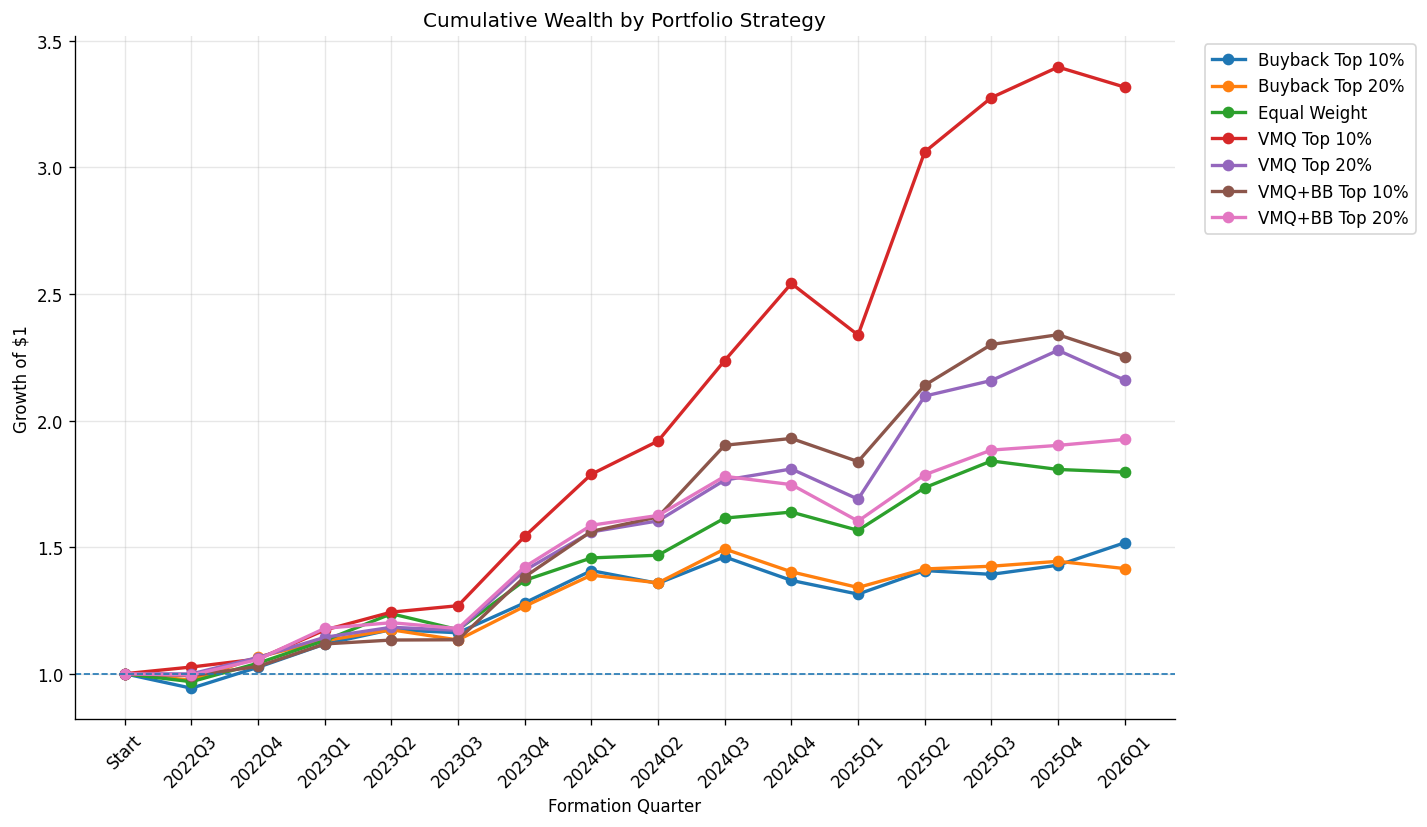

In [49]:
# Plot cumulative wealth for each strategy... growth of $1.. Chat did help immensly with visualizations because I hate coding them

wealth_data = (portfolio_returns.sort_values(["strategy", "formation_period"]).copy())

wealth_data["cumulative_wealth"] = (
    wealth_data
    .groupby("strategy")["gross_return"]
    .transform(
        lambda returns: (1 + returns).cumprod()
    )
)

periods = sorted(wealth_data["formation_period"].unique())

x = np.arange(len(periods) + 1)

plt.figure(figsize=(12, 7))

for strategy, group in wealth_data.groupby("strategy"):         # Yeah I did not write this whatsoever

    group = (
        group
        .set_index("formation_period")
        .reindex(periods)
    )

    wealth = np.concatenate(
        [
            [1.0],
            group["cumulative_wealth"].values
        ]
    )

    plt.plot(
        x,
        wealth,
        marker="o",
        linewidth=2,
        label=strategy
    )


plt.axhline(
    1,
    linestyle="--",
    linewidth=1
)

plt.title("Cumulative Wealth by Portfolio Strategy")
plt.xlabel("Formation Quarter")
plt.ylabel("Growth of $1")

plt.xticks(
    x,
    ["Start"] + [str(period) for period in periods],
    rotation=45
)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [50]:
# Compare annualized returns across transaction costs scenarios

cost_results = performance_table[
    performance_table["return_type"].isin(
        [
            "Gross",
            "Net 10 bps",
            "Net 25 bps",
            "Net 50 bps"
        ])][
    [
        "strategy",
        "return_type",
        "annualized_return"]].copy()


cost_results["annualized_return"] = (cost_results["annualized_return"] * 100)
cost_results

,strategy,return_type,annualized_return
0,Buyback Top 10%,Gross,11.761094
1,Buyback Top 20%,Gross,9.707091
2,Equal Weight,Gross,16.906927
3,VMQ Top 10%,Gross,37.679340
4,VMQ Top 20%,Gross,22.794578
5,VMQ+BB Top 10%,Gross,24.176938
6,VMQ+BB Top 20%,Gross,19.093915
7,Buyback Top 10%,Net 10 bps,11.353575
8,Buyback Top 20%,Net 10 bps,9.318076
9,Equal Weight,Net 10 bps,16.530542


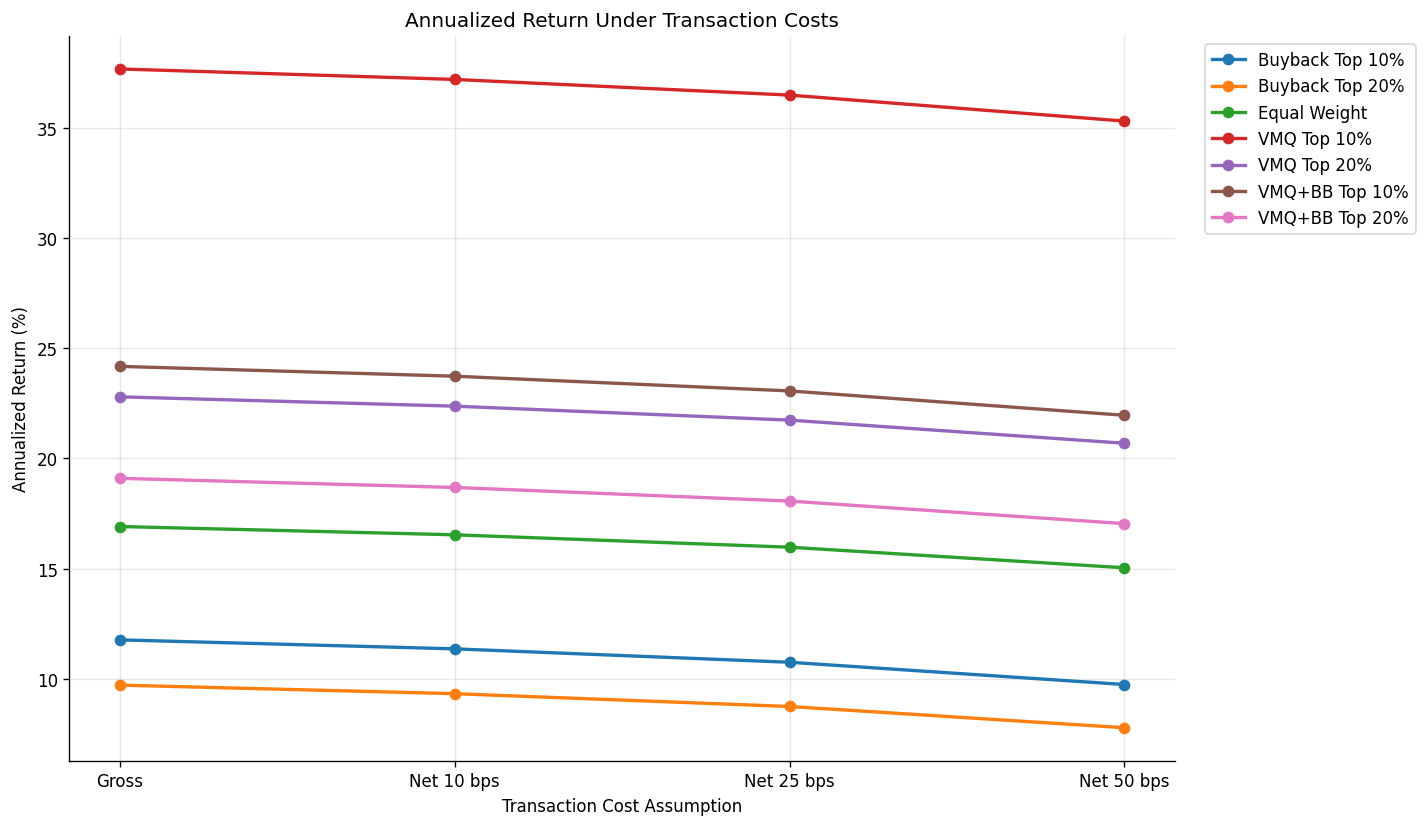

In [51]:
# Plot transaction-cost sensitivity.... ChatGPT made all the code for this, not even sure I like the graph but sure I'll keep it

cost_order = [
    "Gross",
    "Net 10 bps",
    "Net 25 bps",
    "Net 50 bps"
]

plt.figure(
    figsize=(12, 7)
)

for strategy, group in cost_results.groupby("strategy"):

    group = (
        group
        .set_index("return_type")
        .reindex(cost_order)
        .reset_index()
    )

    plt.plot(
        group["return_type"],
        group["annualized_return"],
        marker="o",
        linewidth=2,
        label=strategy
    )


plt.title(
    "Annualized Return Under Transaction Costs"
)

plt.xlabel(
    "Transaction Cost Assumption"
)

plt.ylabel(
    "Annualized Return (%)"
)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [52]:
# Average portfolio turnover by strategy

turnover_summary = (
    portfolio_returns
    .groupby("strategy", as_index=False)
    .agg(
        average_turnover=("turnover", "mean")
    )
)

turnover_summary["average_turnover_pct"] = (turnover_summary["average_turnover"] * 100)

turnover_summary = turnover_summary.sort_values("average_turnover_pct", ascending=False)

turnover_summary

,strategy,average_turnover,average_turnover_pct
5,VMQ+BB Top 10%,0.947786,94.778577
0,Buyback Top 10%,0.935816,93.581619
3,VMQ Top 10%,0.933011,93.301071
4,VMQ Top 20%,0.906553,90.655343
1,Buyback Top 20%,0.906125,90.612478
6,VMQ+BB Top 20%,0.905257,90.525718
2,Equal Weight,0.834513,83.451341


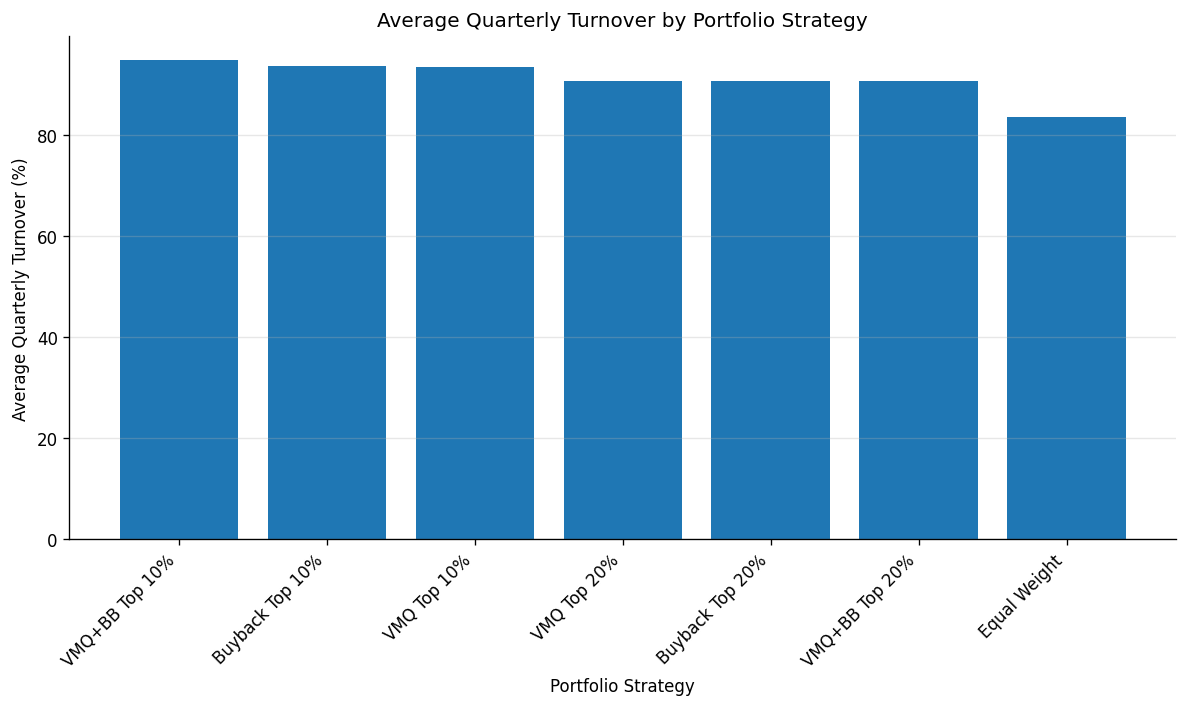

In [53]:
# Plot average turnover... I actually wrote this graph... once again probably not useful

plt.figure(figsize=(10, 6))

plt.bar(turnover_summary["strategy"], turnover_summary["average_turnover_pct"])

plt.title("Average Quarterly Turnover by Portfolio Strategy")

plt.xlabel("Portfolio Strategy")

plt.ylabel("Average Quarterly Turnover (%)")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [54]:
# Save FF5 + Momentum factor exposures with HC3 t-stats and p-values

factor_exposure_results = []
ff5_mom_factors = ["Mkt-RF", "SMB", "HML", "RMW", "CMA", "Mom"]

for strategy in regression_data["strategy"].unique():
    
    strategy_data = regression_data[regression_data["strategy"] == strategy].sort_values("formation_period").copy()
    
    y = strategy_data["excess_return"]
    X = sm.add_constant(strategy_data[ff5_mom_factors])

    model = sm.OLS(y, 
                   X, 
                   missing="drop").fit(cov_type="HC3",
        use_t= True)
    alpha_ci = model.conf_int().loc["const"]

    factor_exposure_results.append({
        "strategy": strategy,
        "alpha": model.params["const"],
        "alpha_t": model.tvalues["const"],
        "alpha_p": model.pvalues["const"],
        "alpha_ci_low": alpha_ci.iloc[0],
        "alpha_ci_high": alpha_ci.iloc[1],

        "market_beta": model.params["Mkt-RF"],
        "market_t": model.tvalues["Mkt-RF"],
        "market_p": model.pvalues["Mkt-RF"],

        "size_beta": model.params["SMB"],
        "size_t": model.tvalues["SMB"],
        "size_p": model.pvalues["SMB"],

        "value_beta": model.params["HML"],
        "value_t": model.tvalues["HML"],
        "value_p": model.pvalues["HML"],

        "profitability_beta": model.params["RMW"],
        "profitability_t": model.tvalues["RMW"],
        "profitability_p": model.pvalues["RMW"],

        "investment_beta": model.params["CMA"],
        "investment_t": model.tvalues["CMA"],
        "investment_p": model.pvalues["CMA"],

        "momentum_beta": model.params["Mom"],
        "momentum_t": model.tvalues["Mom"],
        "momentum_p": model.pvalues["Mom"],

        "r_squared": model.rsquared
    })

factor_exposures = pd.DataFrame(factor_exposure_results)


# Detailed factor regression table

factor_exposures_detailed = factor_exposures.copy()
factor_exposures_detailed[["alpha", "alpha_ci_low", "alpha_ci_high"]] *= 100

factor_exposures_detailed = factor_exposures_detailed.round({
    "alpha": 2, "alpha_t": 2, "alpha_p": 3,
    "alpha_ci_low": 2, "alpha_ci_high": 2,
    "market_beta": 2, "market_t": 2, "market_p": 3,
    "size_beta": 2, "size_t": 2, "size_p": 3,
    "value_beta": 2, "value_t": 2, "value_p": 3,
    "profitability_beta": 2, "profitability_t": 2, "profitability_p": 3,
    "investment_beta": 2, "investment_t": 2, "investment_p": 3,
    "momentum_beta": 2, "momentum_t": 2, "momentum_p": 3,
    "r_squared": 3
})

factor_exposures_detailed = factor_exposures_detailed.rename(columns={
    "strategy": "Strategy",
    "alpha": "Alpha (% per quarter)",
    "alpha_t": "Alpha t-stat",
    "alpha_p": "Alpha p-value",
    "alpha_ci_low": "Alpha CI Low (%)",
    "alpha_ci_high": "Alpha CI High (%)",
    "market_beta": "Market Beta",
    "market_t": "Market t-stat",
    "market_p": "Market p-value",
    "size_beta": "Size Beta",
    "size_t": "Size t-stat",
    "size_p": "Size p-value",
    "value_beta": "Value Beta",
    "value_t": "Value t-stat",
    "value_p": "Value p-value",
    "profitability_beta": "Profitability Beta",
    "profitability_t": "Profitability t-stat",
    "profitability_p": "Profitability p-value",
    "investment_beta": "Investment Beta",
    "investment_t": "Investment t-stat",
    "investment_p": "Investment p-value",
    "momentum_beta": "Momentum Beta",
    "momentum_t": "Momentum t-stat",
    "momentum_p": "Momentum p-value",
    "r_squared": "R Squared"
})

print("Detailed factor regression results")
display(factor_exposures_detailed)


# Final project summary using results already calculated earlier

final_rows = []

# Buyback portfolios on their own
for strategy in ["Buyback Top 10%", "Buyback Top 20%"]:
    row = factor_exposures[factor_exposures["strategy"] == strategy].iloc[0]

    final_rows.append({
        "Portfolio / Comparison": strategy,
        "What Is Being Estimated": "FF5 + Momentum factor-adjusted alpha",
        "Estimated Quarterly Result (pp)": row["alpha"] * 100,
        "t-stat": row["alpha_t"],
        "p-value": row["alpha_p"],
        "95% CI (pp)": f"[{row['alpha_ci_low'] * 100:.2f}, {row['alpha_ci_high'] * 100:.2f}]"
    })

# Incremental effect of adding BB to VMQ
for strategy, comparison in [
    ("Top 10% Difference", "VMQ+BB Top 10% minus VMQ Top 10%"),
    ("Top 20% Difference", "VMQ+BB Top 20% minus VMQ Top 20%")
]:
    row = difference_results[(difference_results["strategy"] == strategy) & (difference_results["model"] == "FF5 + Momentum")].iloc[0]

    estimate = row["alpha"]
    t_stat = row["alpha_t_stat"]
    se = abs(estimate / t_stat) if t_stat != 0 else np.nan
    ci_low, ci_high = estimate - 1.96 * se, estimate + 1.96 * se

    final_rows.append({
        "Portfolio / Comparison": comparison,
        "What Is Being Estimated": "Change in FF5 + Momentum alpha from adding BB",
        "Estimated Quarterly Result (pp)": estimate * 100,
        "t-stat": t_stat,
        "p-value": row["alpha_p_value"],
        "95% CI (pp)": f"[{ci_low * 100:.2f}, {ci_high * 100:.2f}]"
    })

# Stocks added by BB versus stocks removed from VMQ
sub_ci = substitution_model.conf_int().iloc[0]

final_rows.append({
    "Portfolio / Comparison": "BB-added stocks minus VMQ-removed stocks",
    "What Is Being Estimated": "Average difference in subsequent quarterly returns",
    "Estimated Quarterly Result (pp)": substitution_returns.mean() * 100,
    "t-stat": substitution_model.tvalues[0],
    "p-value": substitution_model.pvalues[0],
    "95% CI (pp)": f"[{sub_ci.iloc[0] * 100:.2f}, {sub_ci.iloc[1] * 100:.2f}]"
})

final_project_summary = pd.DataFrame(final_rows).round({
    "Estimated Quarterly Result (pp)": 2,
    "t-stat": 2,
    "p-value": 3
})

print("Final project summary")
display(final_project_summary)

Detailed factor regression results


,Strategy,Alpha (% per quarter),Alpha t-stat,Alpha p-value,Alpha CI Low (%),Alpha CI High (%),Market Beta,Market t-stat,Market p-value,Size Beta,Size t-stat,Size p-value,Value Beta,Value t-stat,Value p-value,Profitability Beta,Profitability t-stat,Profitability p-value,Investment Beta,Investment t-stat,Investment p-value,Momentum Beta,Momentum t-stat,Momentum p-value,R Squared
0,Buyback Top 10%,0.80,0.24,0.818,-6.99,8.60,0.62,1.50,0.173,0.10,0.17,0.869,-0.03,-0.08,0.938,0.06,0.18,0.861,0.55,0.69,0.511,-0.23,-0.35,0.736,0.569
1,Buyback Top 20%,-0.85,-0.40,0.698,-5.71,4.01,0.84,2.58,0.033,0.12,0.27,0.794,0.13,0.38,0.711,0.10,0.34,0.741,0.22,0.48,0.646,-0.14,-0.34,0.743,0.691
2,Equal Weight,0.61,0.47,0.650,-2.37,3.59,1.00,3.33,0.010,0.37,0.76,0.467,0.01,0.02,0.986,0.05,0.18,0.865,0.17,0.46,0.658,-0.13,-0.62,0.553,0.890
3,VMQ Top 10%,5.47,1.85,0.101,-1.33,12.27,0.97,1.88,0.097,0.01,0.02,0.985,-0.56,-0.80,0.445,-0.88,-0.99,0.353,0.52,0.45,0.662,0.26,1.08,0.313,0.791
4,VMQ Top 20%,2.23,0.90,0.396,-3.50,7.96,0.98,2.01,0.080,-0.22,-0.36,0.730,-0.24,-0.36,0.728,-0.83,-1.15,0.283,0.69,0.75,0.474,-0.07,-0.27,0.797,0.803
5,VMQ+BB Top 10%,1.24,0.56,0.592,-3.89,6.37,1.16,3.05,0.016,0.17,0.34,0.743,0.18,0.38,0.713,-0.35,-0.54,0.602,-0.06,-0.08,0.942,0.01,0.03,0.974,0.718
6,VMQ+BB Top 20%,1.00,0.31,0.762,-6.33,8.33,1.03,1.96,0.086,0.33,0.55,0.598,0.07,0.10,0.920,-0.16,-0.36,0.728,0.14,0.18,0.859,-0.12,-0.17,0.870,0.734


Final project summary


,Portfolio / Comparison,What Is Being Estimated,Estimated Quarterly Result (pp),t-stat,p-value,95% CI (pp)
0,Buyback Top 10%,FF5 + Momentum factor-adjusted alpha,0.80,0.24,0.818,"[-6.99, 8.60]"
1,Buyback Top 20%,FF5 + Momentum factor-adjusted alpha,-0.85,-0.40,0.698,"[-5.71, 4.01]"
2,VMQ+BB Top 10% minus VMQ Top 10%,Change in FF5 + Momentum alpha from adding BB,-4.23,-1.93,0.089,"[-8.51, 0.06]"
3,VMQ+BB Top 20% minus VMQ Top 20%,Change in FF5 + Momentum alpha from adding BB,-1.23,-0.29,0.783,"[-9.70, 7.23]"
4,BB-added stocks minus VMQ-removed stocks,Average difference in subsequent quarterly ret...,-7.74,-2.20,0.045,"[-15.28, -0.21]"
